# City Brain — Proposal-Aligned EDA
**COMP 9130 Final Project — Group 5**

This notebook performs exploratory data analysis on the **4 core datasets** required by our proposal:
1. **Pavement Condition Rating** (~8,000 segments) — PCI scores + distress sub-scores
2. **311 Service Requests** (~180,000 records, 2019–2025) — citizen complaint data
3. **Weather Data** (Environment Canada, 2019–2025) — temperature, precipitation, freeze-thaw
4. **Infrastructure Condition Report** (~8,000 segments) — segment age, material, repair history

**Goals:**
- Validate data quality, missing values, and class distribution for each dataset
- Derive the risk label (PCI >= 70 → Low, 40–69 → Medium, < 40 → High) and check class imbalance
- Construct time-series features (complaint frequency, weather rolling windows)
- Verify segment ID join consistency across all 4 datasets
- Engineer key features: freeze-thaw cycles, cumulative precipitation, complaint frequency

---
## Part 0 — Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('Environment ready.')

Environment ready.


### 0.1 Download datasets from Vancouver Open Data & Environment Canada

We pull the 4 core datasets directly from public APIs. If files already exist locally, we skip the download.

In [2]:
import os, urllib.request

DATA_DIR = '../data/'
os.makedirs(DATA_DIR, exist_ok=True)

# Vancouver Open Data API endpoints (CSV export)
DATASETS = {
    'pavement_condition.csv':
        'https://opendata.vancouver.ca/api/explore/v2.1/catalog/datasets/pavement-condition-rating/exports/csv?limit=-1&timezone=America%2FVancouver&use_labels=true&epsg=4326',
    '311_service_requests.csv':
        'https://opendata.vancouver.ca/api/explore/v2.1/catalog/datasets/3-1-1-service-requests/exports/csv?limit=-1&timezone=America%2FVancouver&use_labels=true&epsg=4326',
    'infrastructure_condition.csv':
        'https://opendata.vancouver.ca/api/explore/v2.1/catalog/datasets/pavement-condition-rating/exports/csv?limit=-1&timezone=America%2FVancouver&use_labels=true&epsg=4326',
}

# Environment Canada bulk weather data (Vancouver Int'l Airport, Climate ID 1108395)
# We download yearly CSV files for 2019-2025 and concatenate them
WEATHER_YEARS = range(2019, 2026)
WEATHER_STATION_ID = 51442  # Vancouver Int'l Airport

for fname, url in DATASETS.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(url, path)
        print(f'  Saved to {path}')
    else:
        print(f'{fname} already exists, skipping.')

# Download weather data year by year
weather_path = os.path.join(DATA_DIR, 'weather_vancouver.csv')
if not os.path.exists(weather_path):
    weather_frames = []
    for year in WEATHER_YEARS:
        url = (f'https://climate.weather.gc.ca/climate_data/bulk_data_e.html'
               f'?format=csv&stationID={WEATHER_STATION_ID}&Year={year}'
               f'&Month=1&Day=1&timeframe=2')  # timeframe=2 = daily
        print(f'Downloading weather data for {year}...')
        try:
            df_w = pd.read_csv(url)
            weather_frames.append(df_w)
        except Exception as e:
            print(f'  Warning: Failed for {year}: {e}')
    if weather_frames:
        df_weather_all = pd.concat(weather_frames, ignore_index=True)
        df_weather_all.to_csv(weather_path, index=False)
        print(f'Weather data saved to {weather_path}')
else:
    print('weather_vancouver.csv already exists, skipping.')

print('\nAll downloads complete.')

  Saved to ../data/pavement_condition.csv
  Saved to ../data/311_service_requests.csv
  Saved to ../data/infrastructure_condition.csv
Weather data saved to ../data/weather_vancouver.csv

All downloads complete.


In [3]:
# Load all 4 datasets
# Vancouver Open Data exports use semicolon delimiter
df_pavement = pd.read_csv(os.path.join(DATA_DIR, 'pavement_condition.csv'), sep=';', on_bad_lines='skip')
df_311 = pd.read_csv(os.path.join(DATA_DIR, '311_service_requests.csv'), sep=';', on_bad_lines='skip')
df_weather = pd.read_csv(os.path.join(DATA_DIR, 'weather_vancouver.csv'))
df_infra = pd.read_csv(os.path.join(DATA_DIR, 'infrastructure_condition.csv'), sep=';', on_bad_lines='skip')

print(f'Pavement Condition: {df_pavement.shape}')
print(f'311 Requests:       {df_311.shape}')
print(f'Weather:            {df_weather.shape}')
print(f'Infrastructure:     {df_infra.shape}')


Pavement Condition: (9016, 8)
311 Requests:       (1155936, 13)
Weather:            (2557, 31)
Infrastructure:     (9016, 8)


---
## Part 1 — Dataset Overview & Quality Check

For each dataset: shape, dtypes, missing values percentage, and sample rows.

In [4]:
def dataset_overview(df, name):
    """Print shape, dtypes, and missing value summary for a dataframe."""
    print('=' * 70)
    print(f'Dataset: {name}')
    print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'\nColumn Info:')
    for col in df.columns:
        missing = df[col].isna().sum()
        pct = missing / len(df) * 100
        dtype = df[col].dtype
        print(f'  {col:40s} {str(dtype):12s} missing: {missing:6d} ({pct:.1f}%)')
    print()

dataset_overview(df_pavement, 'Pavement Condition Rating')
dataset_overview(df_311, '311 Service Requests')
dataset_overview(df_weather, 'Weather (Environment Canada)')
dataset_overview(df_infra, 'Infrastructure Condition Report')

Dataset: Pavement Condition Rating
Shape: 9,016 rows x 8 columns

Column Info:
  Year                                     int64        missing:      0 (0.0%)
  Road Name                                object       missing:      0 (0.0%)
  From Street                              object       missing:      0 (0.0%)
  To Street                                object       missing:      0 (0.0%)
  length_(m)                               int64        missing:      0 (0.0%)
  PCI Rating                               object       missing:      0 (0.0%)
  Geom                                     object       missing:      0 (0.0%)
  geo_point_2d                             object       missing:      0 (0.0%)

Dataset: 311 Service Requests
Shape: 1,155,936 rows x 13 columns

Column Info:
  Department                               object       missing:      0 (0.0%)
  Service request type                     object       missing:      0 (0.0%)
  Status                                   object  

In [5]:
# Sample rows for each dataset
print('=== Pavement Condition (first 3 rows) ===')
display(df_pavement.head(3))
print('\n=== 311 Service Requests (first 3 rows) ===')
display(df_311.head(3))
print('\n=== Weather (first 3 rows) ===')
display(df_weather.head(3))
print('\n=== Infrastructure Condition (first 3 rows) ===')
display(df_infra.head(3))

=== Pavement Condition (first 3 rows) ===


,Year,Road Name,From Street,To Street,length_(m),PCI Rating,Geom,geo_point_2d
0,2020,47TH AV,FRONTENAC ST,KIRKLAND ST,89,GOOD,"{""coordinates"": [[-123.02596132078351, 49.2263...","49.22637498558873, -123.02535015595373"
1,2020,62ND AV,LABURNUM ST,ANGUS DRIVE,206,VERY POOR,"{""coordinates"": [[-123.15124781549908, 49.2151...","49.215083474080224, -123.1498338331115"
2,2020,29TH AV,ELGIN ST,ROSS ST,101,POOR,"{""coordinates"": [[-123.08272270544481, 49.2446...","49.244605930447584, -123.08202889157728"



=== 311 Service Requests (first 3 rows) ===


,Department,Service request type,Status,Closure reason,Service request open timestamp,Service request close date,Last modified timestamp,Address,Local area,Channel,Latitude,Longitude,geom
0,PR - Urban Forestry,City and Park Trees Maintenance Case,Close,Further action has been planned,2022-11-05T18:50:00-07:00,2022-11-18,2022-11-18T14:02:05-08:00,859 W 48TH AV,Oakridge,WEB,49.227655,-123.125473,"49.22765461007, -123.12547335288"
1,PR - Urban Forestry,City and Park Trees Maintenance Case,Close,Further action has been planned,2022-11-05T19:03:00-07:00,2022-11-10,2022-12-01T16:07:44-08:00,5185 RUPERT ST,Renfrew-Collingwood,Mobile App,49.237775,-123.041020,"49.2377752669, -123.0410198593"
2,ENG - Sanitation Services,Abandoned Non-Recyclables-Small Case,Close,Issue not found or inaccessible,2023-08-04T14:05:07-07:00,2023-08-20,2023-08-20T21:15:55-07:00,1800 SPYGLASS PLACE,Fairview,Mobile App,49.270928,-123.115176,"49.27092776138, -123.11517645948"



=== Weather (first 3 rows) ===


,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-123.18,49.19,VANCOUVER INTL A,1108395,2019-01-01,2019,1,1,NaN,5.3,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M
1,-123.18,49.19,VANCOUVER INTL A,1108395,2019-01-02,2019,1,2,NaN,5.5,...,0.0,T,3.4,NaN,NaN,NaN,6.0,NaN,41.0,NaN
2,-123.18,49.19,VANCOUVER INTL A,1108395,2019-01-03,2019,1,3,NaN,9.5,...,0.0,NaN,54.8,NaN,NaN,NaN,14.0,NaN,54.0,NaN



=== Infrastructure Condition (first 3 rows) ===


,Year,Road Name,From Street,To Street,length_(m),PCI Rating,Geom,geo_point_2d
0,2020,47TH AV,FRONTENAC ST,KIRKLAND ST,89,GOOD,"{""coordinates"": [[-123.02596132078351, 49.2263...","49.22637498558873, -123.02535015595373"
1,2020,62ND AV,LABURNUM ST,ANGUS DRIVE,206,VERY POOR,"{""coordinates"": [[-123.15124781549908, 49.2151...","49.215083474080224, -123.1498338331115"
2,2020,29TH AV,ELGIN ST,ROSS ST,101,POOR,"{""coordinates"": [[-123.08272270544481, 49.2446...","49.244605930447584, -123.08202889157728"


### 1.1 Missing Value Heatmap

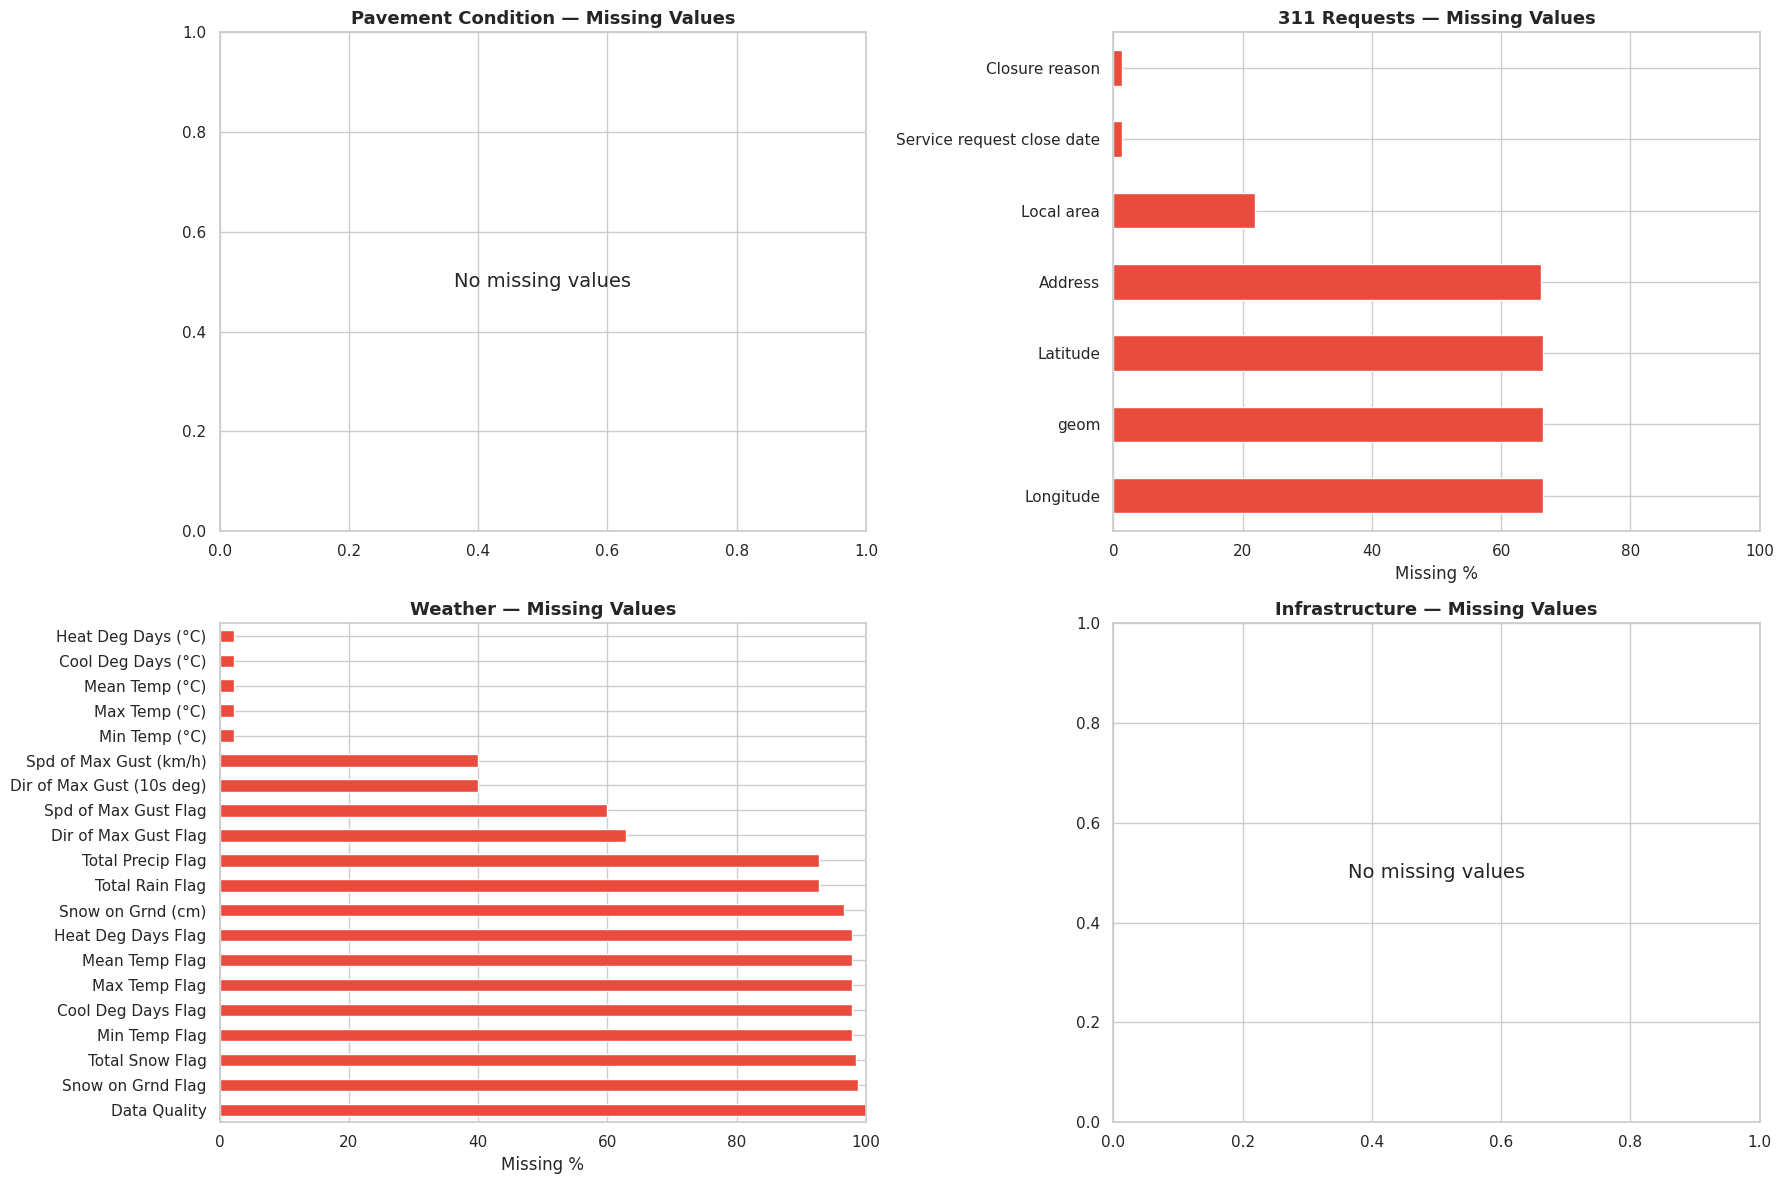

Saved: missing_values.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

datasets_dict = {
    'Pavement Condition': df_pavement,
    '311 Requests': df_311,
    'Weather': df_weather,
    'Infrastructure': df_infra
}

for ax, (name, df) in zip(axes.flat, datasets_dict.items()):
    # Show missing % per column
    missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
    # Only show columns with > 0% missing, up to 20
    missing_pct = missing_pct[missing_pct > 0].head(20)
    if len(missing_pct) == 0:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)
        ax.set_title(f'{name} — Missing Values', fontsize=13, fontweight='bold')
        continue
    missing_pct.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_xlabel('Missing %')
    ax.set_title(f'{name} — Missing Values', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 100)

plt.tight_layout()
# plt.savefig('../EDA/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: missing_values.png')

---
## Part 2 — Pavement Condition Analysis & Risk Label Derivation

The proposal defines risk labels as:
- **Low risk**: PCI >= 70
- **Medium risk**: PCI 40–69
- **High risk**: PCI < 40

This section examines PCI distribution and checks for class imbalance (a known concern from the briefing).

In [7]:
# Identify the PCI rating column
print(f'All pavement columns: {list(df_pavement.columns)}')
print(f'\nDtypes:')
print(df_pavement.dtypes)
print(f'\nSample rows:')
display(df_pavement.head(5))


All pavement columns: ['Year', 'Road Name', 'From Street', 'To Street', 'length_(m)', 'PCI Rating', 'Geom', 'geo_point_2d']

Dtypes:
Year             int64
Road Name       object
From Street     object
To Street       object
length_(m)       int64
PCI Rating      object
Geom            object
geo_point_2d    object
dtype: object

Sample rows:


,Year,Road Name,From Street,To Street,length_(m),PCI Rating,Geom,geo_point_2d
0,2020,47TH AV,FRONTENAC ST,KIRKLAND ST,89,GOOD,"{""coordinates"": [[-123.02596132078351, 49.2263...","49.22637498558873, -123.02535015595373"
1,2020,62ND AV,LABURNUM ST,ANGUS DRIVE,206,VERY POOR,"{""coordinates"": [[-123.15124781549908, 49.2151...","49.215083474080224, -123.1498338331115"
2,2020,29TH AV,ELGIN ST,ROSS ST,101,POOR,"{""coordinates"": [[-123.08272270544481, 49.2446...","49.244605930447584, -123.08202889157728"
3,2020,31ST AV,LANARK ST,DUMFRIES ST,93,VERY POOR,"{""coordinates"": [[-123.07483046938307, 49.2430...","49.243003606888095, -123.07419187431712"
4,2020,53RD AV,KNIGHT ST,LANARK ST,100,VERY GOOD,"{""coordinates"": [[-123.07741967350125, 49.2217...","49.22178989465209, -123.07673312590855"


In [8]:
# === PCI Rating is categorical, not numeric ===
# Values: VERY GOOD, GOOD, FAIR, POOR, VERY POOR, NO DATA
# Map to risk labels for our model

# Auto-detect the PCI/rating column
PCI_COL = None
for col in df_pavement.columns:
    if any(kw in col.lower() for kw in ['pci', 'rating', 'condition']):
        PCI_COL = col
        break

if PCI_COL is None:
    print('ERROR: Could not find PCI column.')
    print(f'Columns: {list(df_pavement.columns)}')
else:
    print(f'Using PCI column: "{PCI_COL}"')
    print(f'\nValue distribution:')
    print(df_pavement[PCI_COL].value_counts())

    # Map categorical PCI ratings to risk labels
    RISK_MAP = {
        'VERY GOOD': 'Low',
        'GOOD': 'Low',
        'FAIR': 'Medium',
        'POOR': 'High',
        'VERY POOR': 'High',
        'NO DATA': np.nan,
    }

    # Also create a numeric score for correlation analysis
    SCORE_MAP = {
        'VERY GOOD': 90,
        'GOOD': 75,
        'FAIR': 55,
        'POOR': 30,
        'VERY POOR': 15,
        'NO DATA': np.nan,
    }

    df_pavement['risk_label'] = df_pavement[PCI_COL].str.upper().str.strip().map(RISK_MAP)
    df_pavement['pci_score'] = df_pavement[PCI_COL].str.upper().str.strip().map(SCORE_MAP)

    print(f'\nRisk label distribution:')
    print(df_pavement['risk_label'].value_counts())
    print(f'\nDerived PCI score stats:')
    print(df_pavement['pci_score'].describe())


Using PCI column: "PCI Rating"

Value distribution:
PCI Rating
GOOD         1876
FAIR         1871
VERY GOOD    1758
VERY POOR    1641
POOR         1440
NO DATA       430
Name: count, dtype: int64

Risk label distribution:
risk_label
Low       3634
High      3081
Medium    1871
Name: count, dtype: int64

Derived PCI score stats:
count    8586.000000
mean       54.698346
std        27.364893
min        15.000000
25%        30.000000
50%        55.000000
75%        75.000000
max        90.000000
Name: pci_score, dtype: float64


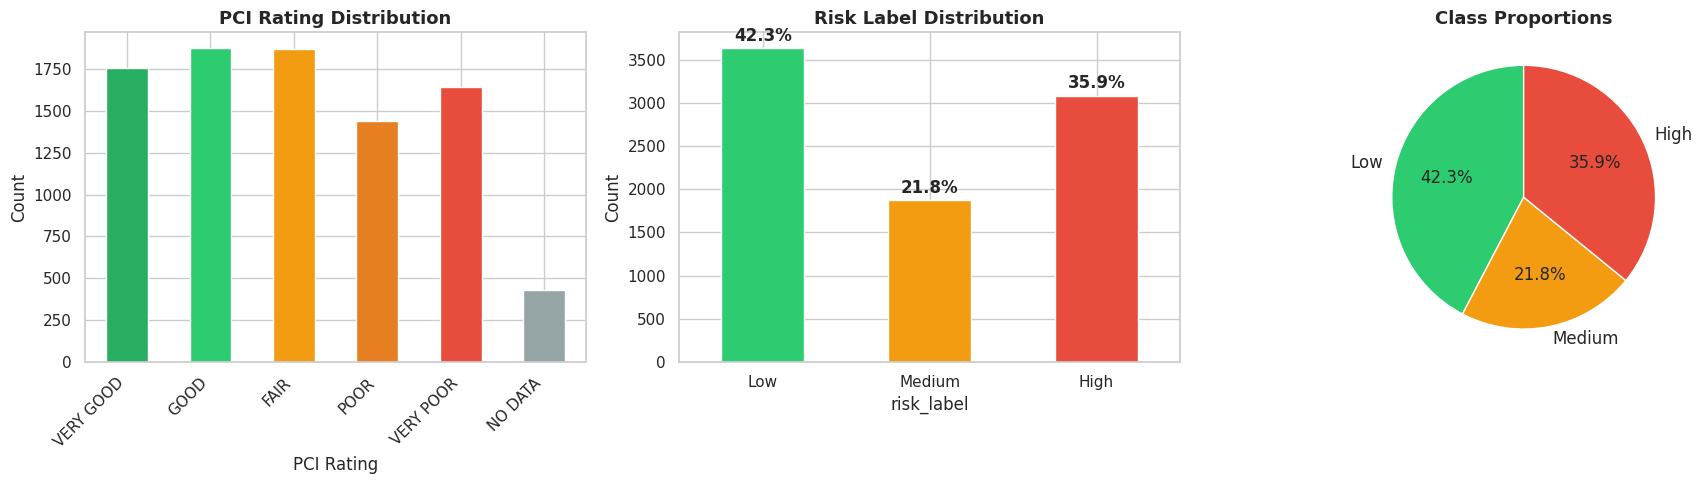


High-risk class: 35.9% — imbalance is manageable.


In [9]:
# === Class distribution visualization ===
if PCI_COL is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) PCI Rating category counts (original labels)
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR', 'NO DATA']
    cat_counts = df_pavement[PCI_COL].str.upper().str.strip().value_counts().reindex(order).dropna()
    cat_colors = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#95a5a6']
    cat_counts.plot(kind='bar', ax=axes[0], color=cat_colors[:len(cat_counts)], edgecolor='white')
    axes[0].set_title('PCI Rating Distribution', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

    # 2) Risk label bar chart
    risk_counts = df_pavement['risk_label'].value_counts().reindex(['Low', 'Medium', 'High']).dropna()
    colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    risk_counts.plot(kind='bar', ax=axes[1], color=[colors.get(c, '#999') for c in risk_counts.index], edgecolor='white')
    axes[1].set_title('Risk Label Distribution', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    total = risk_counts.sum()
    for j, (label, count) in enumerate(risk_counts.items()):
        axes[1].text(j, count + total * 0.01, f'{count/total*100:.1f}%', ha='center', fontweight='bold')

    # 3) Pie chart
    risk_pct = risk_counts / total * 100
    axes[2].pie(risk_pct, labels=risk_pct.index, autopct='%1.1f%%',
                colors=[colors.get(c, '#999') for c in risk_pct.index], startangle=90,
                textprops={'fontsize': 12})
    axes[2].set_title('Class Proportions', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Flag imbalance
    high_pct = risk_counts.get('High', 0) / total * 100
    if high_pct < 10:
        print(f'\n*** CLASS IMBALANCE WARNING: High-risk class is only {high_pct:.1f}% ***')
        print('Recommendation: Stratified split + class weights or SMOTE.')
    else:
        print(f'\nHigh-risk class: {high_pct:.1f}% — imbalance is manageable.')


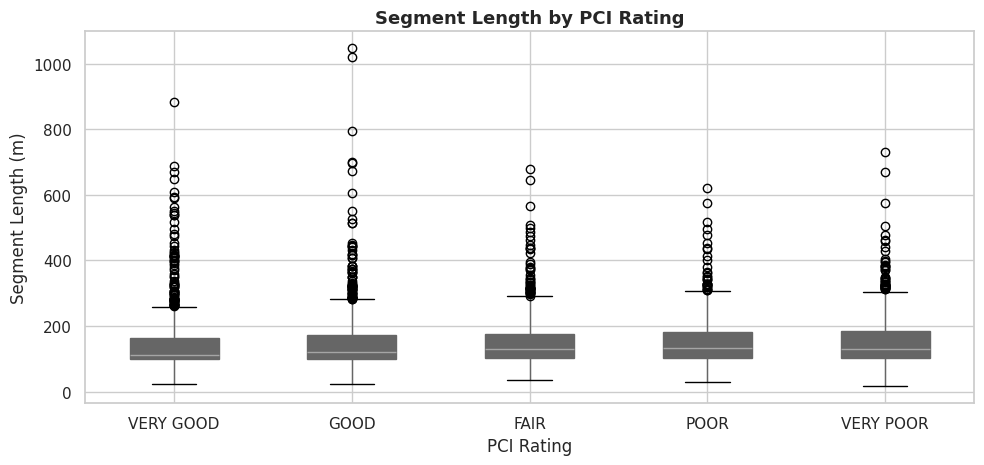

In [10]:
# === PCI Rating vs Segment Length ===
# Since PCI is categorical, check if segment length correlates with condition
if PCI_COL and 'length_(m)' in df_pavement.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR']
    df_plot = df_pavement[df_pavement[PCI_COL].str.upper().str.strip().isin(order)].copy()
    df_plot['_pci'] = pd.Categorical(df_plot[PCI_COL].str.upper().str.strip(), categories=order, ordered=True)
    df_plot.boxplot(column='length_(m)', by='_pci', ax=ax, patch_artist=True)
    ax.set_title('Segment Length by PCI Rating', fontsize=13, fontweight='bold')
    ax.set_xlabel('PCI Rating')
    ax.set_ylabel('Segment Length (m)')
    plt.suptitle('')
    plt.tight_layout()
    plt.show()
else:
    print('No segment length column available for cross-analysis.')


---
## Part 3 — 311 Service Requests Analysis

Key tasks from the briefing:
- Identify road-related complaint types
- Handle deduplication (same pothole → many reports)
- Analyze geographic reporting bias
- Construct per-segment complaint frequency time-series

In [11]:
print(f'311 Requests shape: {df_311.shape}')
print(f'\nColumns: {list(df_311.columns)}')
print(f'\nDate range:')

# Identify date column
date_cols = [c for c in df_311.columns if 'date' in c.lower() or 'time' in c.lower() or 'created' in c.lower()]
print(f'Date columns: {date_cols}')

# Identify category/type column
cat_cols = [c for c in df_311.columns if any(kw in c.lower() for kw in ['type', 'category', 'department', 'service', 'case'])]
print(f'Category columns: {cat_cols}')

311 Requests shape: (1155936, 13)

Columns: ['Department', 'Service request type', 'Status', 'Closure reason', 'Service request open timestamp', 'Service request close date', 'Last modified timestamp', 'Address', 'Local area', 'Channel', 'Latitude', 'Longitude', 'geom']

Date range:
Date columns: ['Service request open timestamp', 'Service request close date', 'Last modified timestamp']
Category columns: ['Department', 'Service request type', 'Service request open timestamp', 'Service request close date']


In [12]:
# === Filter for road/pavement-related complaints ===
# Auto-detect the category column
CAT_COL = None
for col in df_311.columns:
    cl = col.lower()
    if any(kw in cl for kw in ['case_type', 'type', 'category', 'service_name', 'service request type', 'request type']):
        if df_311[col].dtype == 'object':
            CAT_COL = col
            break

if CAT_COL:
    print(f'Using category column: "{CAT_COL}"')
    print(f'\nTop 30 complaint categories:')
    print(df_311[CAT_COL].value_counts().head(30))
else:
    print('Could not auto-detect category column.')
    print('String columns:', [c for c in df_311.columns if df_311[c].dtype == 'object'])


Using category column: "Service request type"

Top 30 complaint categories:
Service request type
Building and Development Inquiry Case     106088
Business Licence Request Case              65843
Missed Green Bin Pickup Case               57520
Garbage Bin Request Case                   52075
City and Park Trees Maintenance Case       46267
Missed Garbage Bin Pickup Case             42362
Mayor and Council Feedback Case            42107
Abandoned Non-Recyclables-Small Case       38123
Green Bin Request Case                     30684
City Services Feedback Case                29108
Parking Enforcement Transfer Case          25831
Parking Enforcement Request Case           24227
General Feedback Case                      23232
Noise on Private Property Case             20605
Abandoned or Uninsured Vehicle Case        20045
Meter Out of Order Internal Audit Case     18708
Public Hearing Feedback Case               18640
Pothole Case                               18311
Animal Concern Case  

In [13]:
# === Filter road-related 311 requests ===
# Common keywords: pothole, road, pavement, street, sidewalk, curb, manhole
ROAD_KEYWORDS = ['pothole', 'road', 'pavement', 'street repair', 'manhole', 'sewer',
                 'curb', 'crack', 'asphalt', 'roadway', 'street light']

if CAT_COL:
    mask = df_311[CAT_COL].str.lower().str.contains('|'.join(ROAD_KEYWORDS), na=False)
    df_311_road = df_311[mask].copy()
    print(f'Road-related 311 requests: {len(df_311_road):,} / {len(df_311):,} ({len(df_311_road)/len(df_311)*100:.1f}%)')
    print(f'\nRoad-related categories:')
    print(df_311_road[CAT_COL].value_counts().head(15))
else:
    # Fallback: search across all string columns
    mask = pd.Series(False, index=df_311.index)
    for col in df_311.select_dtypes(include='object').columns:
        mask |= df_311[col].str.lower().str.contains('|'.join(ROAD_KEYWORDS), na=False)
    df_311_road = df_311[mask].copy()
    print(f'Road-related 311 requests (keyword search): {len(df_311_road):,}')

Road-related 311 requests: 60,259 / 1,155,936 (5.2%)

Road-related categories:
Service request type
Pothole Case                                        18311
Street Light Out Case                               15766
Street Repair Case                                   8527
Sewer Backup Case                                    4739
Street Light Pole Maintenance Case                   2070
Sewer Drainage and Design Inquiry Case               1476
Sewer Maintenance Hole Concern Case                  1420
Residential Street Curbside Sign Request Case        1385
Sewer Operations Inquiry Case                        1275
Sewer Construction Concern Case                      1245
Pavement Marking Maintenance Case                     794
New or Relocate Street Light Pole Case                760
Arterial St. Curbside Sign - New Request Case         719
Commercial Street Curbside Sign Request Case          496
Arterial St. Curbside Sign - Modify Request Case      466
Name: count, dtype: int64


Using 311 date column: "Service request open timestamp"


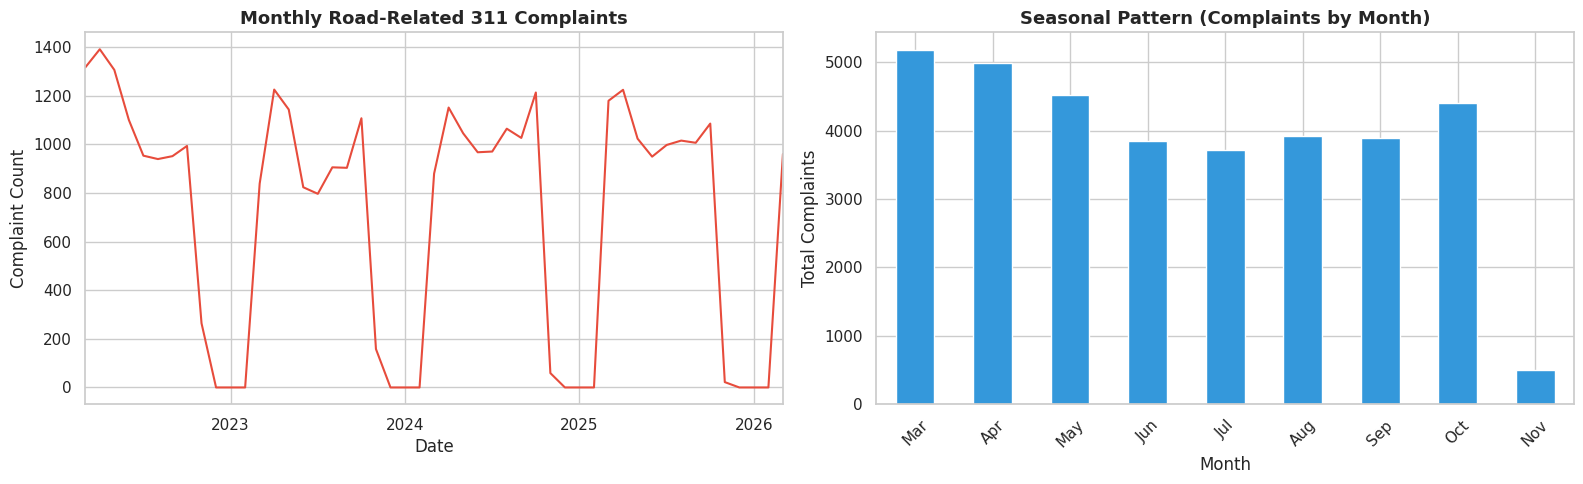

Date range: 2022-03-13 07:24:33-07:00 — 2026-03-30 21:24:36-07:00


In [16]:
# === 311 temporal analysis ===
# Parse date column
DATE_COL_311 = None
for col in df_311.columns:
    cl = col.lower()
    if ('date' in cl or 'created' in cl or 'opened' in cl or 'open' in cl or 'timestamp' in cl):
        # Prefer the 'open' timestamp over 'close' or 'modified'
        if 'close' in cl or 'modified' in cl:
            continue
        DATE_COL_311 = col
        break

# Fallback: any column with 'date' or 'timestamp'
if DATE_COL_311 is None:
    for col in df_311.columns:
        if 'date' in col.lower() or 'timestamp' in col.lower():
            DATE_COL_311 = col
            break

print(f'Using 311 date column: "{DATE_COL_311}"')

if DATE_COL_311:
    df_311_road[DATE_COL_311] = pd.to_datetime(df_311_road[DATE_COL_311], errors='coerce')
    df_311_road = df_311_road.dropna(subset=[DATE_COL_311])

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Monthly complaint volume
    monthly = df_311_road.set_index(DATE_COL_311).resample('M').size()
    monthly.plot(ax=axes[0], color='#e74c3c', linewidth=1.5)
    axes[0].set_title('Monthly Road-Related 311 Complaints', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Complaint Count')

    # Seasonal pattern (month-of-year)
    df_311_road['month'] = df_311_road[DATE_COL_311].dt.month
    seasonal = df_311_road.groupby('month').size()
    seasonal.plot(kind='bar', ax=axes[1], color='#3498db', edgecolor='white')
    axes[1].set_title('Seasonal Pattern (Complaints by Month)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Total Complaints')
    month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    axes[1].set_xticklabels([month_names.get(int(t.get_text()), t.get_text()) for t in axes[1].get_xticklabels()], rotation=45)

    plt.tight_layout()
    plt.show()

    print(f'Date range: {df_311_road[DATE_COL_311].min()} — {df_311_road[DATE_COL_311].max()}')
else:
    print('No date column found in 311 data.')
    print(f'Available columns: {list(df_311.columns)}')


Geographic columns in 311 data: ['Latitude', 'Longitude', 'geom']


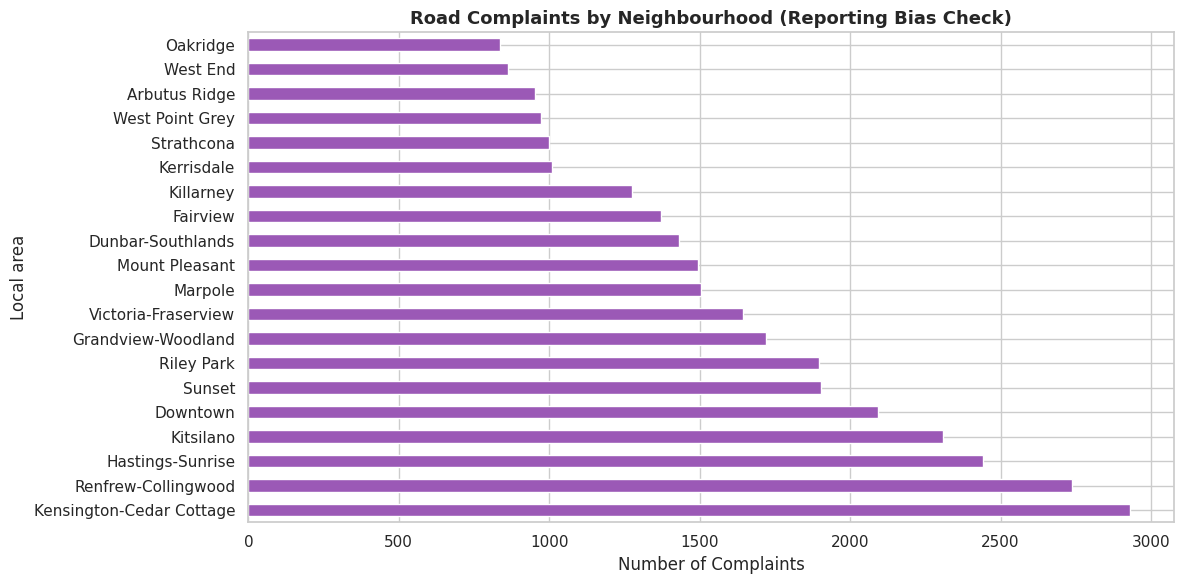

Note: Higher complaint counts may reflect reporting bias, not worse road conditions.


In [17]:
# === Deduplication analysis ===
# Per the briefing: same pothole can generate dozens of reports
# Check for spatial/temporal clustering

geo_cols_311 = [c for c in df_311_road.columns if 'lat' in c.lower() or 'lon' in c.lower() or 'geo' in c.lower() or 'local_area' in c.lower() or 'neighbourhood' in c.lower()]
print(f'Geographic columns in 311 data: {geo_cols_311}')

# If we have a neighborhood/local_area column, show distribution
area_col = None
for col in df_311_road.columns:
    if any(kw in col.lower() for kw in ['local_area', 'neighbourhood', 'neighborhood', 'area']):
        area_col = col
        break

if area_col:
    fig, ax = plt.subplots(figsize=(12, 6))
    area_counts = df_311_road[area_col].value_counts().head(20)
    area_counts.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='white')
    ax.set_title('Road Complaints by Neighbourhood (Reporting Bias Check)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Complaints')
    plt.tight_layout()
    # plt.savefig('../EDA/311_neighbourhood_bias.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Note: Higher complaint counts may reflect reporting bias, not worse road conditions.')

---
## Part 4 — Weather Data Analysis

Key features to engineer (from the briefing):
1. **Freeze-thaw cycle count**: days where min temp crosses 0°C
2. **Cumulative precipitation**: rolling sum
3. **Maximum single-day rainfall**

Vancouver freeze-thaw season: Dec–Mar; peak rainfall: Oct–Mar.

In [18]:
print(f'Weather data shape: {df_weather.shape}')
print(f'\nColumns: {list(df_weather.columns)}')
print(f'\nFirst 3 rows:')
display(df_weather.head(3))

Weather data shape: (2557, 31)

Columns: ['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)', 'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)', 'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag', 'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)', 'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag', 'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)', 'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)', 'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag']

First 3 rows:


,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-123.18,49.19,VANCOUVER INTL A,1108395,2019-01-01,2019,1,1,NaN,5.3,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M
1,-123.18,49.19,VANCOUVER INTL A,1108395,2019-01-02,2019,1,2,NaN,5.5,...,0.0,T,3.4,NaN,NaN,NaN,6.0,NaN,41.0,NaN
2,-123.18,49.19,VANCOUVER INTL A,1108395,2019-01-03,2019,1,3,NaN,9.5,...,0.0,NaN,54.8,NaN,NaN,NaN,14.0,NaN,54.0,NaN


In [19]:
# === Parse weather columns ===
# Environment Canada daily CSV columns:
# 'Date/Time', 'Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)', 'Total Precip (mm)', etc.

# Auto-detect date column
date_col_w = None
for col in df_weather.columns:
    if 'date' in col.lower():
        date_col_w = col
        break

if date_col_w:
    df_weather[date_col_w] = pd.to_datetime(df_weather[date_col_w], errors='coerce')
    df_weather = df_weather.dropna(subset=[date_col_w]).sort_values(date_col_w)
    print(f'Date range: {df_weather[date_col_w].min()} — {df_weather[date_col_w].max()}')

# Auto-detect temperature and precipitation columns
# IMPORTANT: Exclude 'Flag' columns — they are quality markers, not data
temp_min_col = None
temp_max_col = None
precip_col = None

for col in df_weather.columns:
    cl = col.lower()
    if 'flag' in cl:
        continue  # Skip all flag columns
    if 'min' in cl and 'temp' in cl:
        temp_min_col = col
    elif 'max' in cl and 'temp' in cl:
        temp_max_col = col
    elif 'total precip' in cl:
        precip_col = col

# Fallback for precip
if precip_col is None:
    for col in df_weather.columns:
        if 'precip' in col.lower() and 'flag' not in col.lower():
            precip_col = col
            break

print(f'Min Temp column: {temp_min_col}')
print(f'Max Temp column: {temp_max_col}')
print(f'Precipitation column: {precip_col}')

# Quick sanity check
for col in [temp_min_col, temp_max_col, precip_col]:
    if col:
        nn = df_weather[col].notna().sum()
        print(f'  {col}: {nn}/{len(df_weather)} non-null values')


Date range: 2019-01-01 00:00:00 — 2025-12-31 00:00:00
Min Temp column: Min Temp (°C)
Max Temp column: Max Temp (°C)
Precipitation column: Total Precip (mm)
  Min Temp (°C): 2500/2557 non-null values
  Max Temp (°C): 2500/2557 non-null values
  Total Precip (mm): 2547/2557 non-null values


In [20]:
# === Missing value analysis for weather ===
if date_col_w:
    weather_key_cols = [c for c in [temp_min_col, temp_max_col, precip_col] if c is not None]

    # Check for gaps in the date series
    date_range = pd.date_range(df_weather[date_col_w].min(), df_weather[date_col_w].max(), freq='D')
    missing_dates = date_range.difference(df_weather[date_col_w])
    print(f'Missing dates in time series: {len(missing_dates)}')
    if len(missing_dates) > 0 and len(missing_dates) <= 20:
        print(f'Missing dates: {list(missing_dates.strftime("%Y-%m-%d"))}')
    elif len(missing_dates) > 20:
        print(f'First 10 missing: {list(missing_dates[:10].strftime("%Y-%m-%d"))}')

    # Missing values in key columns (actual data, not flags)
    for col in weather_key_cols:
        vals = pd.to_numeric(df_weather[col], errors='coerce')
        missing = vals.isna().sum()
        # Check for consecutive missing stretches
        is_missing = vals.isna()
        if is_missing.any():
            groups = (is_missing != is_missing.shift()).cumsum()
            streak_lengths = is_missing.groupby(groups).sum()
            max_streak = int(streak_lengths.max())
            print(f'  {col}: {missing} missing ({missing/len(df_weather)*100:.1f}%), max consecutive gap: {max_streak} days')
            if max_streak > 3:
                print(f'    WARNING: Gaps > 3 days — consider monthly climatological averages for imputation.')
        else:
            print(f'  {col}: 0 missing')


Missing dates in time series: 0
  Min Temp (°C): 57 missing (2.2%), max consecutive gap: 2 days
  Max Temp (°C): 57 missing (2.2%), max consecutive gap: 2 days
  Total Precip (mm): 10 missing (0.4%), max consecutive gap: 2 days


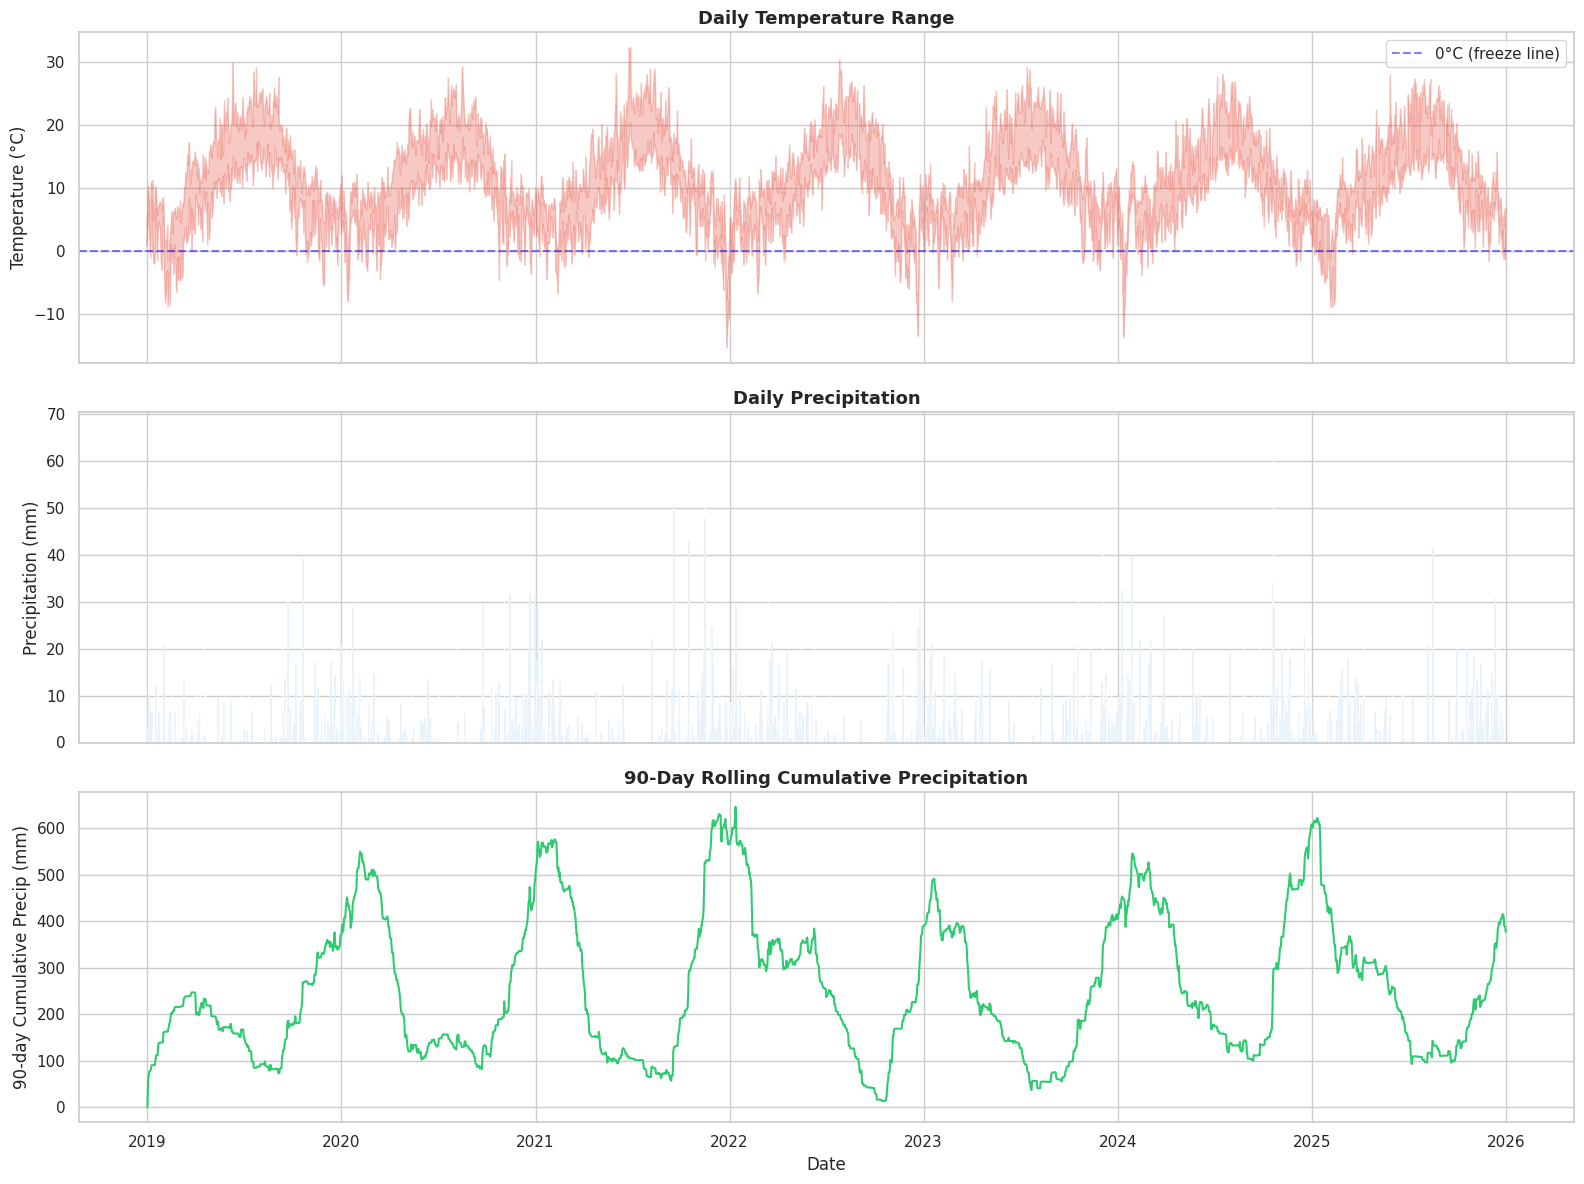

In [21]:
# === Weather time-series visualization ===
if date_col_w and temp_min_col and precip_col:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    # 1) Temperature range
    if temp_max_col:
        axes[0].fill_between(df_weather[date_col_w],
                             pd.to_numeric(df_weather[temp_min_col], errors='coerce'),
                             pd.to_numeric(df_weather[temp_max_col], errors='coerce'),
                             alpha=0.3, color='#e74c3c')
    axes[0].axhline(0, color='blue', linestyle='--', alpha=0.5, label='0°C (freeze line)')
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].set_title('Daily Temperature Range', fontsize=13, fontweight='bold')
    axes[0].legend()

    # 2) Daily precipitation
    precip_vals = pd.to_numeric(df_weather[precip_col], errors='coerce')
    axes[1].bar(df_weather[date_col_w], precip_vals, width=1, color='#3498db', alpha=0.7)
    axes[1].set_ylabel('Precipitation (mm)')
    axes[1].set_title('Daily Precipitation', fontsize=13, fontweight='bold')

    # 3) 90-day rolling cumulative precipitation
    rolling_precip = precip_vals.rolling(90, min_periods=1).sum()
    axes[2].plot(df_weather[date_col_w], rolling_precip, color='#2ecc71', linewidth=1.5)
    axes[2].set_ylabel('90-day Cumulative Precip (mm)')
    axes[2].set_title('90-Day Rolling Cumulative Precipitation', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Date')

    plt.tight_layout()
    # plt.savefig('../EDA/weather_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()

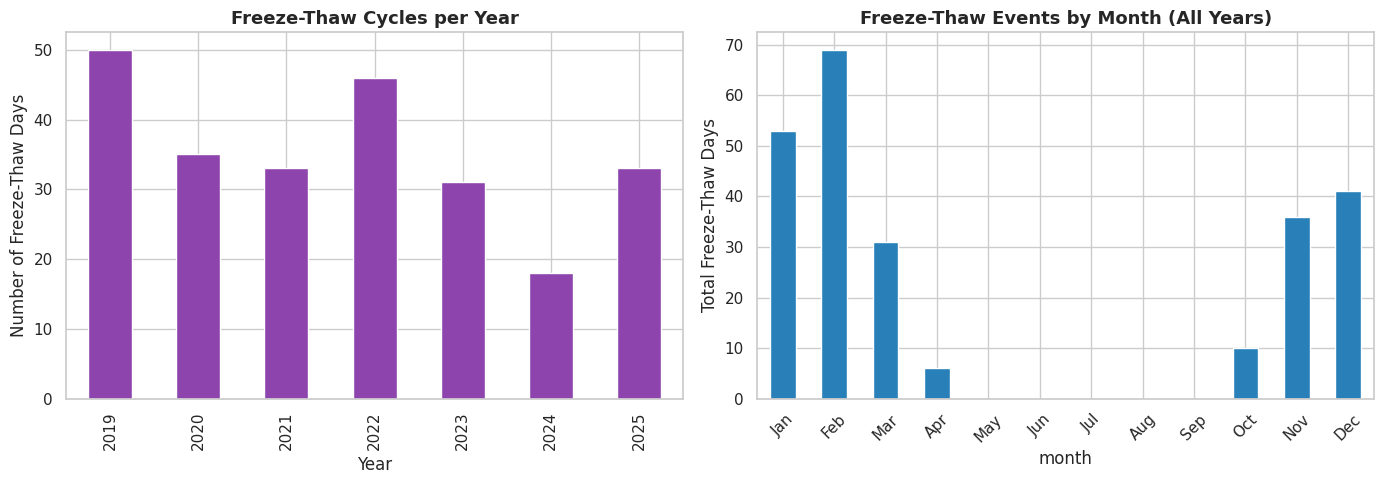

Total freeze-thaw days: 246
Mean per year: 35.1
Peak months: Dec, Jan, Feb, Mar (as expected for Vancouver)


In [22]:
# === Freeze-thaw cycle analysis ===
if temp_min_col and temp_max_col and date_col_w:
    tmin = pd.to_numeric(df_weather[temp_min_col], errors='coerce')
    tmax = pd.to_numeric(df_weather[temp_max_col], errors='coerce')

    # A freeze-thaw day: min temp < 0 AND max temp > 0
    df_weather['freeze_thaw'] = (tmin < 0) & (tmax > 0)

    # Count per year
    df_weather['year'] = df_weather[date_col_w].dt.year
    ft_by_year = df_weather.groupby('year')['freeze_thaw'].sum()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Annual freeze-thaw cycles
    ft_by_year.plot(kind='bar', ax=axes[0], color='#8e44ad', edgecolor='white')
    axes[0].set_title('Freeze-Thaw Cycles per Year', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Number of Freeze-Thaw Days')
    axes[0].set_xlabel('Year')

    # Monthly distribution of freeze-thaw events
    df_weather['month'] = df_weather[date_col_w].dt.month
    ft_by_month = df_weather.groupby('month')['freeze_thaw'].sum()
    ft_by_month.plot(kind='bar', ax=axes[1], color='#2980b9', edgecolor='white')
    axes[1].set_title('Freeze-Thaw Events by Month (All Years)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Total Freeze-Thaw Days')
    axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

    plt.tight_layout()
    # plt.savefig('../EDA/freeze_thaw_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # 90-day rolling freeze-thaw count
    df_weather['ft_rolling_90d'] = df_weather['freeze_thaw'].astype(int).rolling(90, min_periods=1).sum()
    print(f'Total freeze-thaw days: {df_weather["freeze_thaw"].sum()}')
    print(f'Mean per year: {ft_by_year.mean():.1f}')
    print(f'Peak months: Dec, Jan, Feb, Mar (as expected for Vancouver)')

---
## Part 5 — Infrastructure Condition Analysis

Key features: segment age, surface material, repair history, traffic volume.

Critical issue from briefing: **missing last-repair-date** — check missingness and decide on imputation.

In [23]:
print(f'Infrastructure data shape: {df_infra.shape}')
print(f'\nColumns: {list(df_infra.columns)}')
display(df_infra.head(3))

Infrastructure data shape: (9016, 8)

Columns: ['Year', 'Road Name', 'From Street', 'To Street', 'length_(m)', 'PCI Rating', 'Geom', 'geo_point_2d']


,Year,Road Name,From Street,To Street,length_(m),PCI Rating,Geom,geo_point_2d
0,2020,47TH AV,FRONTENAC ST,KIRKLAND ST,89,GOOD,"{""coordinates"": [[-123.02596132078351, 49.2263...","49.22637498558873, -123.02535015595373"
1,2020,62ND AV,LABURNUM ST,ANGUS DRIVE,206,VERY POOR,"{""coordinates"": [[-123.15124781549908, 49.2151...","49.215083474080224, -123.1498338331115"
2,2020,29TH AV,ELGIN ST,ROSS ST,101,POOR,"{""coordinates"": [[-123.08272270544481, 49.2446...","49.244605930447584, -123.08202889157728"


In [24]:
# === Identify key infrastructure columns ===
# Look for: age, material/surface type, repair date, traffic volume

col_mapping = {}
for col in df_infra.columns:
    cl = col.lower()
    if 'age' in cl or 'year' in cl and 'built' in cl:
        col_mapping['age'] = col
    elif any(kw in cl for kw in ['material', 'surface', 'type', 'pavement_type']):
        col_mapping['material'] = col
    elif any(kw in cl for kw in ['repair', 'last_repair', 'rehab', 'maintenance']):
        col_mapping['repair'] = col
    elif any(kw in cl for kw in ['traffic', 'aadt', 'volume', 'count']):
        col_mapping['traffic'] = col

print('Detected column mapping:')
for key, col in col_mapping.items():
    missing = df_infra[col].isna().sum()
    print(f'  {key:12s} -> "{col}" (missing: {missing}, {missing/len(df_infra)*100:.1f}%)')

# Check repair date missingness (flagged in briefing)
if 'repair' in col_mapping:
    repair_col = col_mapping['repair']
    repair_missing_pct = df_infra[repair_col].isna().mean() * 100
    print(f'\n*** Repair date missingness: {repair_missing_pct:.1f}% ***')
    if repair_missing_pct > 30:
        print('Recommendation: Convert to binary has_repair_history (1/0) feature.')
    elif repair_missing_pct > 0:
        print('Recommendation: Conditional mean imputation (conditioned on age + material).')

Detected column mapping:


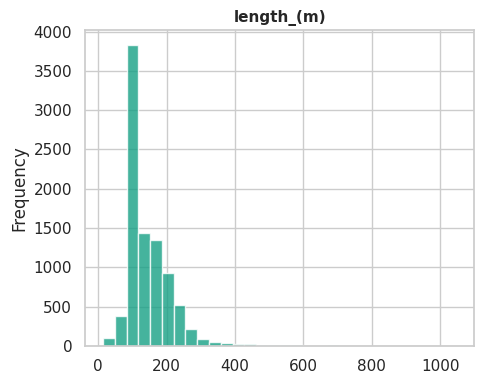

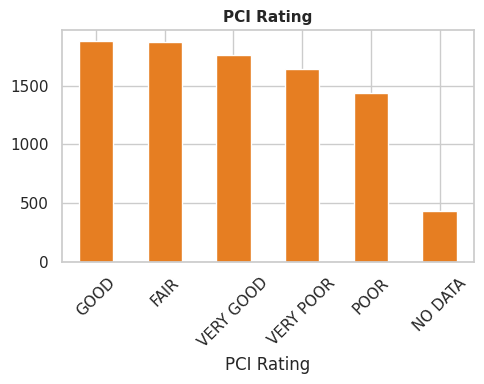

In [25]:
# === Infrastructure feature distributions ===
numeric_infra_cols = df_infra.select_dtypes(include=[np.number]).columns.tolist()
# Remove geo columns
numeric_infra_cols = [c for c in numeric_infra_cols if not any(kw in c.lower() for kw in ['lat', 'lon', 'geo', 'x', 'y'])]

if numeric_infra_cols:
    n_cols = min(len(numeric_infra_cols), 4)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4))
    if n_cols == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_infra_cols[:4]):
        df_infra[col].dropna().hist(bins=30, ax=ax, color='#16a085', edgecolor='white', alpha=0.8)
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_ylabel('Frequency')
    plt.tight_layout()
    # plt.savefig('../EDA/infrastructure_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

# Categorical features
cat_infra_cols = df_infra.select_dtypes(include='object').columns.tolist()
cat_infra_cols = [c for c in cat_infra_cols if 'geo' not in c.lower() and 'geom' not in c.lower() and df_infra[c].nunique() < 20]

if cat_infra_cols:
    n_cols = min(len(cat_infra_cols), 3)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4))
    if n_cols == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_infra_cols[:3]):
        df_infra[col].value_counts().head(10).plot(kind='bar', ax=ax, color='#e67e22', edgecolor='white')
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    # plt.savefig('../EDA/infrastructure_categorical.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Part 6 — Cross-Dataset Join Validation

**Critical check from the briefing:** All 4 datasets are joined on road segment ID. We must verify:
1. ID format consistency (capitalization, prefixes, null values)
2. Join coverage (how many segments can be matched)
3. Silent data loss during merge

In [26]:
# === Identify potential join keys across datasets ===

def find_id_columns(df, name):
    """Find columns that could serve as segment/street IDs."""
    candidates = []
    for col in df.columns:
        cl = col.lower()
        if any(kw in cl for kw in ['segment', 'street', 'block', 'hblock', 'id', 'road_id', 'asset']):
            candidates.append(col)
    print(f'{name}:')
    for col in candidates:
        nunique = df[col].nunique()
        null_count = df[col].isna().sum()
        sample = df[col].dropna().head(3).tolist()
        print(f'  {col}: {nunique} unique, {null_count} nulls, sample: {sample}')
    if not candidates:
        print('  (no obvious ID columns found)')
    return candidates

print('=== Join Key Candidates ===')
print()
id_pavement = find_id_columns(df_pavement, 'Pavement Condition')
print()
id_311 = find_id_columns(df_311_road, '311 Requests (road-related)')
print()
id_infra = find_id_columns(df_infra, 'Infrastructure Condition')

=== Join Key Candidates ===

Pavement Condition:
  From Street: 873 unique, 0 nulls, sample: ['FRONTENAC ST', 'LABURNUM ST', 'ELGIN ST']
  To Street: 876 unique, 0 nulls, sample: ['KIRKLAND ST', 'ANGUS DRIVE', 'ROSS ST']

311 Requests (road-related):
  (no obvious ID columns found)

Infrastructure Condition:
  From Street: 873 unique, 0 nulls, sample: ['FRONTENAC ST', 'LABURNUM ST', 'ELGIN ST']
  To Street: 876 unique, 0 nulls, sample: ['KIRKLAND ST', 'ANGUS DRIVE', 'ROSS ST']


In [27]:
# === Attempt join between pavement and infrastructure datasets ===
# These two should share the most segment IDs

# Try to find a common ID column
common_cols = set(df_pavement.columns) & set(df_infra.columns)
print(f'Columns shared between Pavement and Infrastructure: {common_cols}')

# If common ID exists, test join
join_col = None
for col in common_cols:
    if any(kw in col.lower() for kw in ['id', 'segment', 'street', 'block', 'hblock']):
        join_col = col
        break

if join_col:
    # Standardize IDs for comparison
    pav_ids = set(df_pavement[join_col].dropna().astype(str).str.strip().str.upper())
    infra_ids = set(df_infra[join_col].dropna().astype(str).str.strip().str.upper())

    overlap = pav_ids & infra_ids
    only_pav = pav_ids - infra_ids
    only_infra = infra_ids - pav_ids

    print(f'\nJoin on "{join_col}":')
    print(f'  Pavement segments:       {len(pav_ids):,}')
    print(f'  Infrastructure segments:  {len(infra_ids):,}')
    print(f'  Overlap (matched):        {len(overlap):,} ({len(overlap)/max(len(pav_ids),1)*100:.1f}%)')
    print(f'  Only in Pavement:         {len(only_pav):,}')
    print(f'  Only in Infrastructure:   {len(only_infra):,}')

    if len(overlap) / max(len(pav_ids), 1) < 0.5:
        print('\n*** WARNING: Low join coverage. Check ID format consistency. ***')
        print(f'  Sample Pavement IDs:     {list(pav_ids)[:5]}')
        print(f'  Sample Infrastructure IDs: {list(infra_ids)[:5]}')
else:
    print('\nNo common ID column found between Pavement and Infrastructure.')
    print('Will need to use spatial join (lat/lon proximity matching).')

    # Check if both have geographic columns
    pav_geo = [c for c in df_pavement.columns if 'geo' in c.lower() or 'lat' in c.lower()]
    infra_geo = [c for c in df_infra.columns if 'geo' in c.lower() or 'lat' in c.lower()]
    print(f'  Pavement geo columns: {pav_geo}')
    print(f'  Infrastructure geo columns: {infra_geo}')

Columns shared between Pavement and Infrastructure: {'Year', 'length_(m)', 'To Street', 'Geom', 'From Street', 'Road Name', 'PCI Rating', 'geo_point_2d'}

Join on "To Street":
  Pavement segments:       876
  Infrastructure segments:  876
  Overlap (matched):        876 (100.0%)
  Only in Pavement:         0
  Only in Infrastructure:   0


In [28]:
# === 311 to Pavement joinability ===
# 311 requests need to be mapped to road segments (likely spatial join)

# Check for street name columns as a secondary join key
street_cols_311 = [c for c in df_311_road.columns if 'street' in c.lower() or 'address' in c.lower()]
street_cols_pav = [c for c in df_pavement.columns if 'street' in c.lower() or 'name' in c.lower() or 'hblock' in c.lower()]

print('Street name columns:')
print(f'  311 data:     {street_cols_311}')
print(f'  Pavement:     {street_cols_pav}')

# Summary of join strategy
print('\n=== Join Strategy Summary ===')
print('  Pavement <-> Infrastructure:  Segment ID or spatial join')
print('  Pavement <-> 311:             Spatial join (map complaint lat/lon to nearest segment)')
print('  Pavement <-> Weather:         Temporal join (weather is city-wide, applied to all segments)')

Street name columns:
  311 data:     ['Address']
  Pavement:     ['Road Name', 'From Street', 'To Street']

=== Join Strategy Summary ===
  Pavement <-> Infrastructure:  Segment ID or spatial join
  Pavement <-> 311:             Spatial join (map complaint lat/lon to nearest segment)
  Pavement <-> Weather:         Temporal join (weather is city-wide, applied to all segments)


---
## Part 7 — Feature Engineering Preview

Preview the key engineered features that will feed into the 4-branch fusion model:
1. **PCI branch**: PCI score + distress sub-scores (static per segment)
2. **Weather branch (BiLSTM input)**: 90-day rolling freeze-thaw count, cumulative precipitation, max single-day rainfall
3. **311 branch (BiLSTM input)**: Per-segment complaint frequency (30/90-day rolling windows)
4. **Infrastructure branch**: Segment age, surface material (one-hot), repair history flag

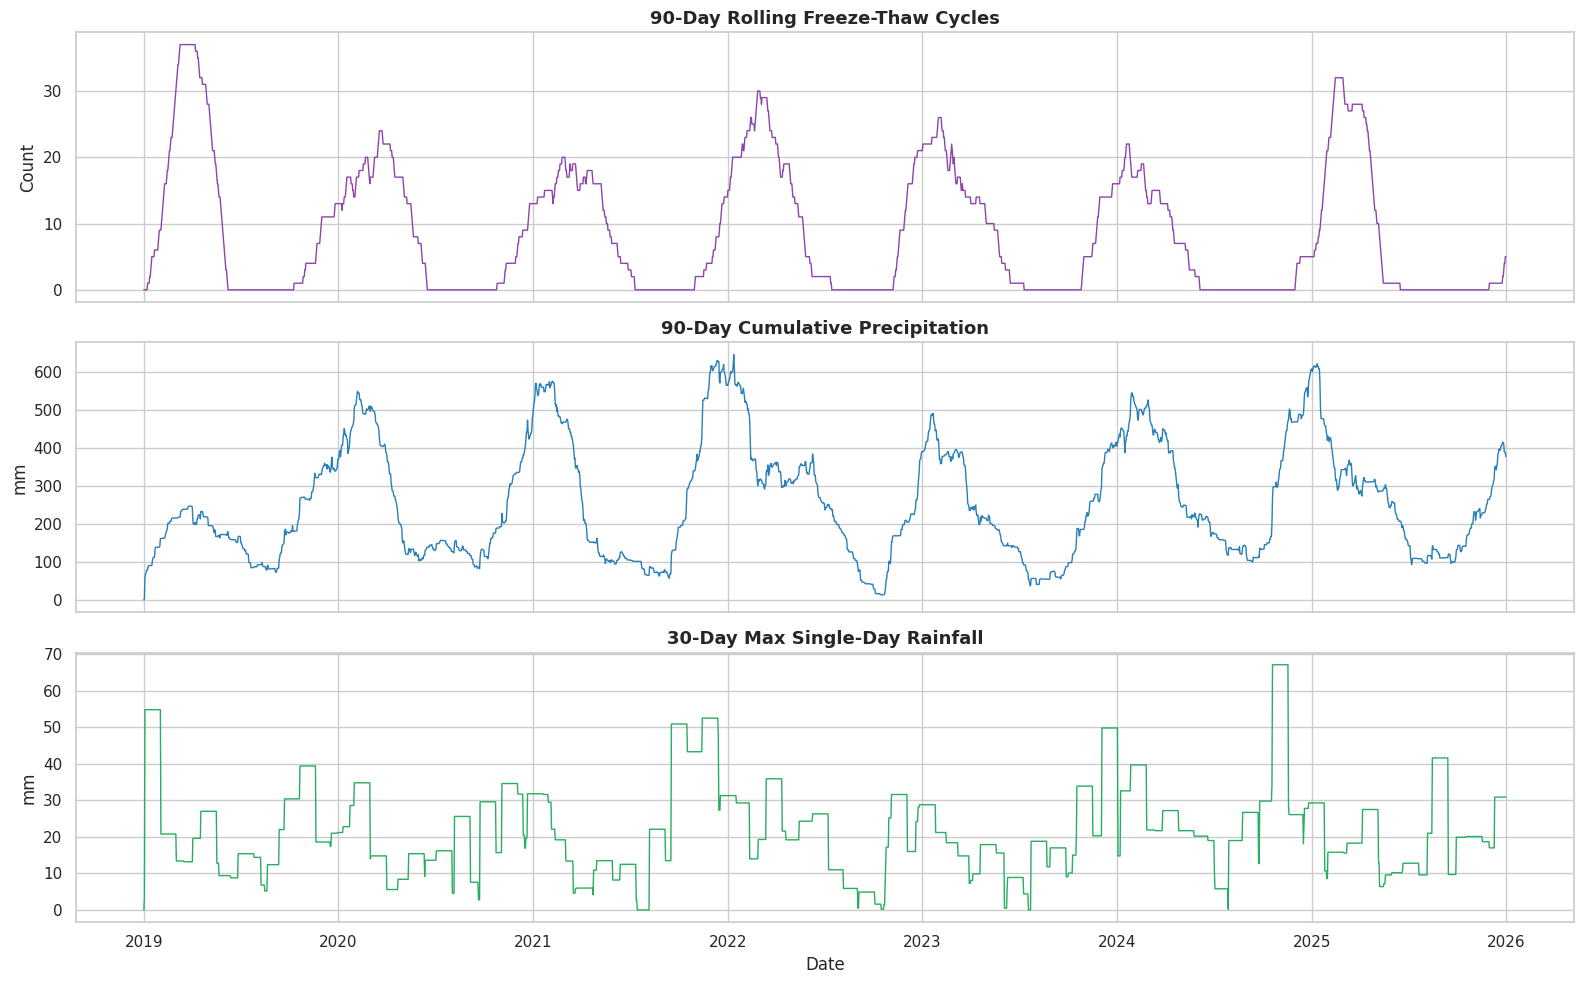

Weather features summary:
                                date  freeze_thaw_90d  cumul_precip_90d  \
count                           2557          2557.00           2557.00   
mean   2022-07-01 23:59:59.999999744             8.50            256.98   
min              2019-01-01 00:00:00             0.00              0.00   
25%              2020-10-01 00:00:00             0.00            132.60   
50%              2022-07-02 00:00:00             4.00            218.60   
75%              2024-04-01 00:00:00            16.00            363.70   
max              2025-12-31 00:00:00            37.00            646.30   
std                              NaN             9.63            150.18   

       max_precip_30d  
count         2557.00  
mean            22.11  
min              0.00  
25%             13.50  
50%             19.90  
75%             29.30  
max             67.10  
std             12.69  


In [29]:
# === Weather feature engineering preview ===
if date_col_w and precip_col and temp_min_col and temp_max_col:
    precip_vals = pd.to_numeric(df_weather[precip_col], errors='coerce').fillna(0)

    weather_features = pd.DataFrame({
        'date': df_weather[date_col_w],
        'freeze_thaw_90d': df_weather['freeze_thaw'].astype(int).rolling(90, min_periods=1).sum(),
        'cumul_precip_90d': precip_vals.rolling(90, min_periods=1).sum(),
        'max_precip_30d': precip_vals.rolling(30, min_periods=1).max(),
    })

    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    axes[0].plot(weather_features['date'], weather_features['freeze_thaw_90d'], color='#8e44ad', linewidth=1)
    axes[0].set_ylabel('Count')
    axes[0].set_title('90-Day Rolling Freeze-Thaw Cycles', fontsize=13, fontweight='bold')

    axes[1].plot(weather_features['date'], weather_features['cumul_precip_90d'], color='#2980b9', linewidth=1)
    axes[1].set_ylabel('mm')
    axes[1].set_title('90-Day Cumulative Precipitation', fontsize=13, fontweight='bold')

    axes[2].plot(weather_features['date'], weather_features['max_precip_30d'], color='#27ae60', linewidth=1)
    axes[2].set_ylabel('mm')
    axes[2].set_title('30-Day Max Single-Day Rainfall', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Date')

    plt.tight_layout()
    # plt.savefig('../EDA/weather_features_preview.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Weather features summary:')
    print(weather_features.describe().round(2))

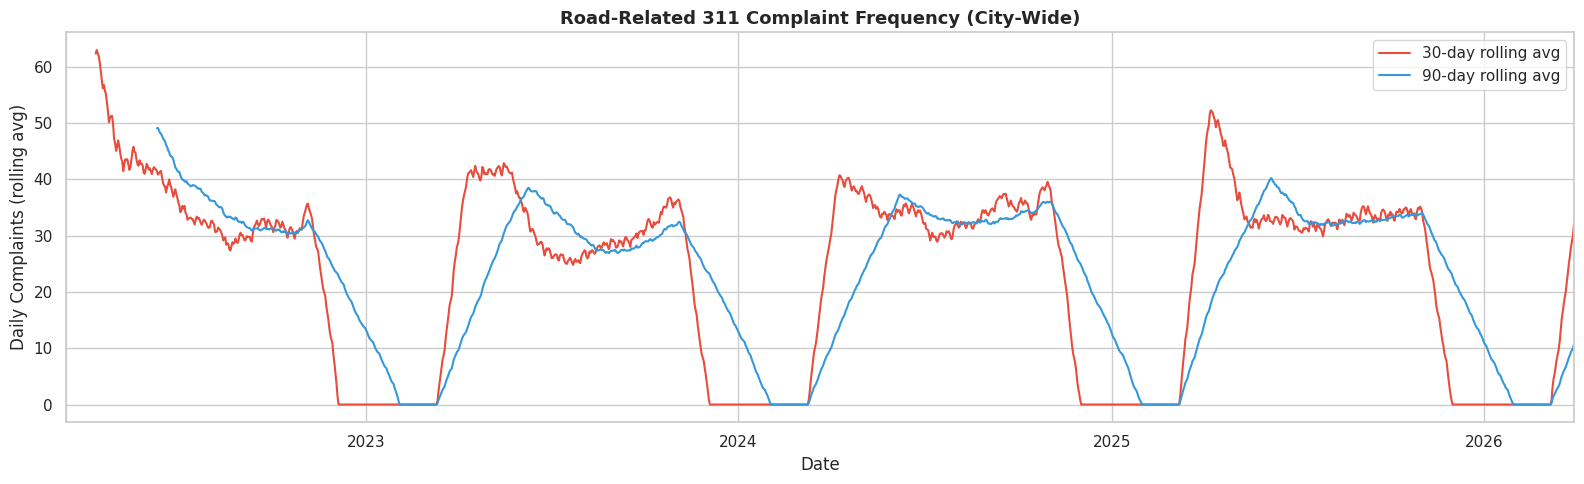

Total road-related complaints: 34,978
Average daily complaints: 23.6


In [30]:
# === 311 complaint frequency time-series preview ===
# Per the briefing: aggregate by segment + 7-day window to handle deduplication

if DATE_COL_311:
    # Overall: show 30-day and 90-day rolling complaint frequency (city-wide)
    daily_complaints = df_311_road.set_index(DATE_COL_311).resample('D').size()

    fig, ax = plt.subplots(figsize=(16, 5))
    daily_complaints.rolling(30).mean().plot(ax=ax, label='30-day rolling avg', color='#e74c3c', linewidth=1.5)
    daily_complaints.rolling(90).mean().plot(ax=ax, label='90-day rolling avg', color='#3498db', linewidth=1.5)
    ax.set_title('Road-Related 311 Complaint Frequency (City-Wide)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Daily Complaints (rolling avg)')
    ax.set_xlabel('Date')
    ax.legend()

    plt.tight_layout()
    # plt.savefig('../EDA/311_frequency_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Total road-related complaints: {len(df_311_road):,}')
    print(f'Average daily complaints: {daily_complaints.mean():.1f}')

---
## Part 8 — Correlation Analysis

Examine correlations between available numeric features to preview feature interactions.

311 monthly range: 2022-03-31 00:00:00 to 2026-03-31 00:00:00 (49 months)
Weather monthly range: 2019-01-31 00:00:00 to 2025-12-31 00:00:00 (84 months)
Overlapping months: 46


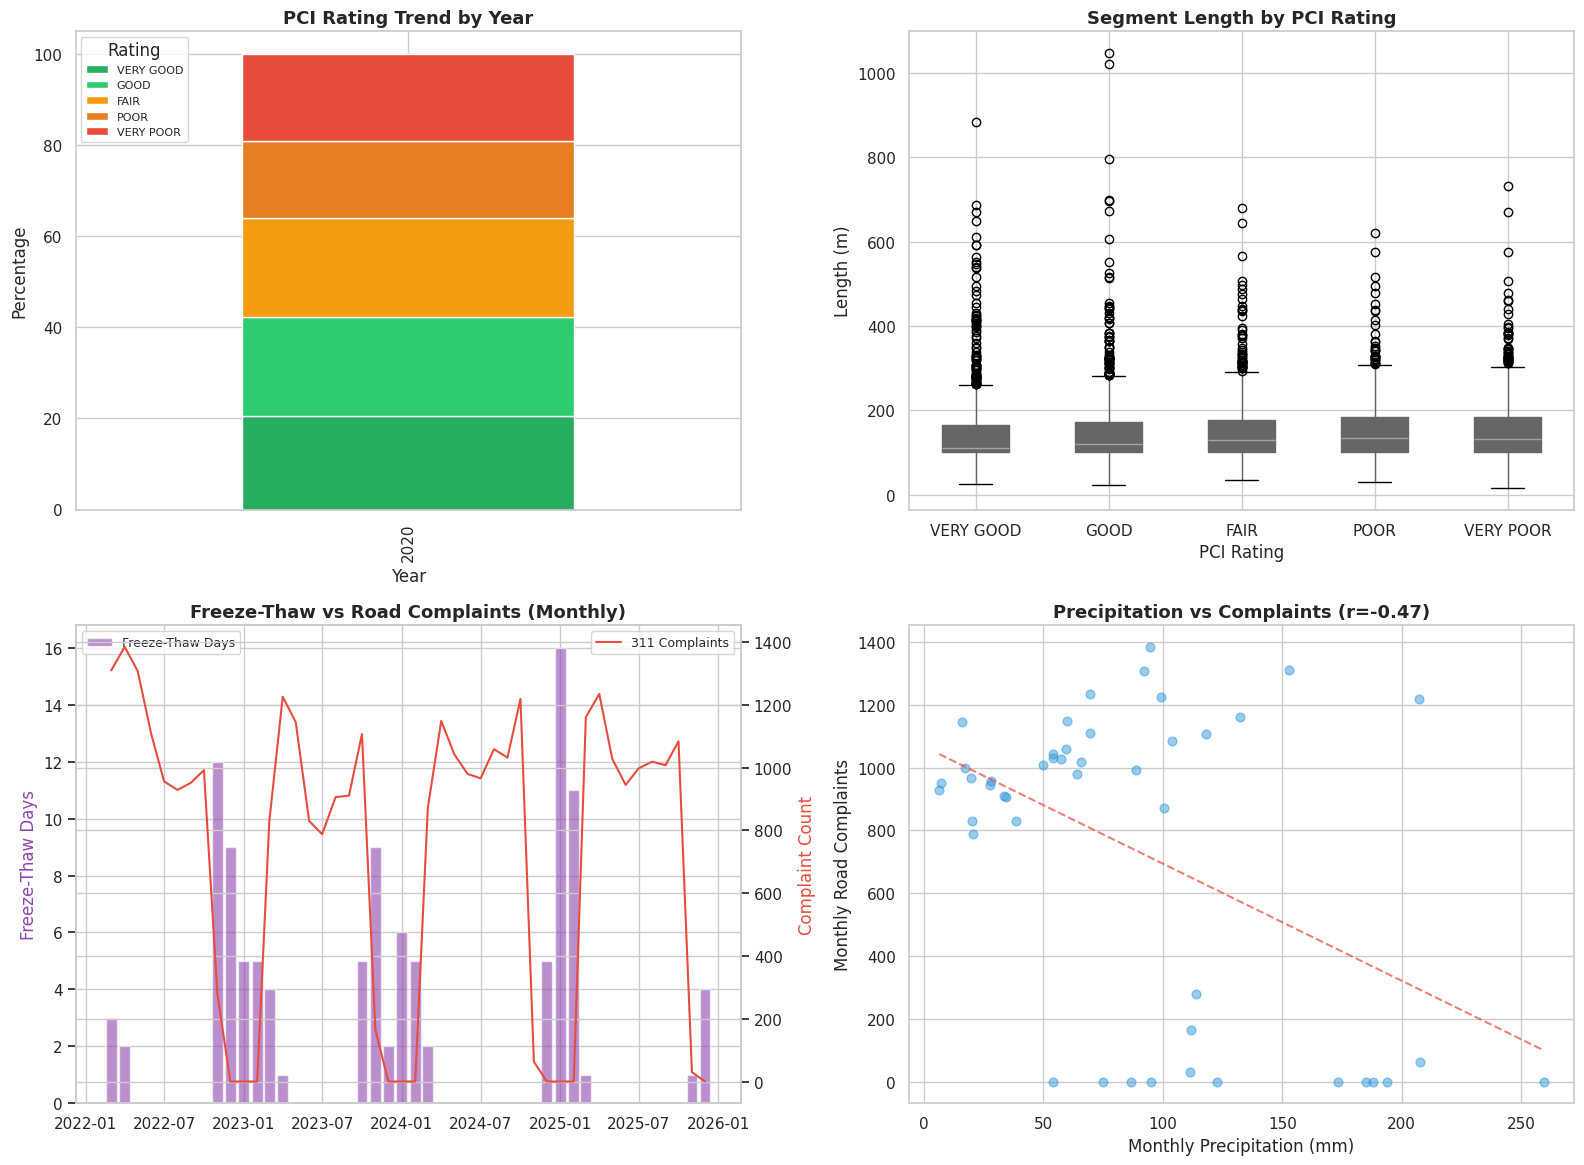

In [33]:
# === Part 8: Cross-Dataset Analysis ===

# Ensure date columns are timezone-naive datetime for consistent resampling
if DATE_COL_311 and DATE_COL_311 in df_311_road.columns:
    df_311_road[DATE_COL_311] = pd.to_datetime(df_311_road[DATE_COL_311], errors='coerce', utc=True).dt.tz_localize(None)
if date_col_w and date_col_w in df_weather.columns:
    df_weather[date_col_w] = pd.to_datetime(df_weather[date_col_w], errors='coerce')
    if df_weather[date_col_w].dt.tz is not None:
        df_weather[date_col_w] = df_weather[date_col_w].dt.tz_localize(None)

# Build monthly series
complaints_monthly = None
weather_monthly_ft = None
precip_monthly = None

if DATE_COL_311:
    tmp = df_311_road.dropna(subset=[DATE_COL_311]).copy()
    tmp = tmp.set_index(DATE_COL_311).sort_index()
    complaints_monthly = tmp.resample('M').size()
    print(f'311 monthly range: {complaints_monthly.index.min()} to {complaints_monthly.index.max()} ({len(complaints_monthly)} months)')

if date_col_w and 'freeze_thaw' in df_weather.columns:
    tmp_w = df_weather.dropna(subset=[date_col_w]).copy()
    tmp_w = tmp_w.set_index(date_col_w).sort_index()
    weather_monthly_ft = tmp_w['freeze_thaw'].resample('M').sum()
    if precip_col:
        precip_monthly = pd.to_numeric(tmp_w[precip_col], errors='coerce').resample('M').sum()
    print(f'Weather monthly range: {weather_monthly_ft.index.min()} to {weather_monthly_ft.index.max()} ({len(weather_monthly_ft)} months)')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 1) PCI Rating by Year ---
if PCI_COL and 'Year' in df_pavement.columns:
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR']
    df_pav_clean = df_pavement[df_pavement[PCI_COL].str.upper().str.strip().isin(order)].copy()
    ct = pd.crosstab(df_pav_clean['Year'], df_pav_clean[PCI_COL].str.upper().str.strip(), normalize='index') * 100
    ct = ct[[c for c in order if c in ct.columns]]
    ct.plot(kind='bar', stacked=True, ax=axes[0, 0],
            color=['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
    axes[0, 0].set_title('PCI Rating Trend by Year', fontsize=13, fontweight='bold')
    axes[0, 0].set_ylabel('Percentage')
    axes[0, 0].legend(title='Rating', fontsize=8, loc='upper left')

# --- 2) Segment Length by PCI Rating ---
if PCI_COL and 'length_(m)' in df_pavement.columns:
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR']
    df_pav_clean = df_pavement[df_pavement[PCI_COL].str.upper().str.strip().isin(order)].copy()
    df_pav_clean['_pci'] = pd.Categorical(df_pav_clean[PCI_COL].str.upper().str.strip(), categories=order, ordered=True)
    df_pav_clean.boxplot(column='length_(m)', by='_pci', ax=axes[0, 1], patch_artist=True)
    axes[0, 1].set_title('Segment Length by PCI Rating', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('PCI Rating')
    axes[0, 1].set_ylabel('Length (m)')
    plt.sca(axes[0, 1])
    plt.suptitle('')

# --- 3) Freeze-Thaw vs 311 Complaints ---
if weather_monthly_ft is not None and complaints_monthly is not None:
    # Use merge on Period to avoid timezone/exact-timestamp mismatch
    df_merge = pd.DataFrame({
        'freeze_thaw': weather_monthly_ft.values,
        'month': weather_monthly_ft.index.to_period('M')
    }).merge(
        pd.DataFrame({
            'complaints': complaints_monthly.values,
            'month': complaints_monthly.index.to_period('M')
        }),
        on='month', how='inner'
    )
    print(f'Overlapping months: {len(df_merge)}')
    if len(df_merge) > 0:
        ax3 = axes[1, 0]
        months = df_merge['month'].dt.to_timestamp()
        ax3.bar(months, df_merge['freeze_thaw'], width=25, alpha=0.6, color='#8e44ad', label='Freeze-Thaw Days')
        ax3b = ax3.twinx()
        ax3b.plot(months, df_merge['complaints'], color='#e74c3c', linewidth=1.5, label='311 Complaints')
        ax3.set_title('Freeze-Thaw vs Road Complaints (Monthly)', fontsize=13, fontweight='bold')
        ax3.set_ylabel('Freeze-Thaw Days', color='#8e44ad')
        ax3b.set_ylabel('Complaint Count', color='#e74c3c')
        ax3.legend(loc='upper left', fontsize=9)
        ax3b.legend(loc='upper right', fontsize=9)
    else:
        axes[1, 0].text(0.5, 0.5, 'No overlapping months found', ha='center', va='center')

# --- 4) Precipitation vs 311 Complaints ---
if precip_monthly is not None and complaints_monthly is not None:
    df_merge2 = pd.DataFrame({
        'precip': precip_monthly.values,
        'month': precip_monthly.index.to_period('M')
    }).merge(
        pd.DataFrame({
            'complaints': complaints_monthly.values,
            'month': complaints_monthly.index.to_period('M')
        }),
        on='month', how='inner'
    )
    if len(df_merge2) > 0:
        ax4 = axes[1, 1]
        ax4.scatter(df_merge2['precip'], df_merge2['complaints'], alpha=0.5, color='#3498db', s=40)
        x = df_merge2['precip'].values.astype(float)
        y = df_merge2['complaints'].values.astype(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() > 2:
            from numpy.polynomial.polynomial import polyfit
            b, m = polyfit(x[mask], y[mask], 1)
            xs = np.linspace(x[mask].min(), x[mask].max(), 100)
            ax4.plot(xs, b + m * xs, '--', color='#e74c3c', alpha=0.7)
            corr_val = np.corrcoef(x[mask], y[mask])[0, 1]
            ax4.set_title(f'Precipitation vs Complaints (r={corr_val:.2f})', fontsize=13, fontweight='bold')
        ax4.set_xlabel('Monthly Precipitation (mm)')
        ax4.set_ylabel('Monthly Road Complaints')
    else:
        axes[1, 1].text(0.5, 0.5, 'No overlapping months', ha='center', va='center')

plt.tight_layout()
plt.show()


---
## Part 9 — Summary & Next Steps

In [34]:
print('=' * 70)
print('EDA SUMMARY')
print('=' * 70)

print(f'\n1. PAVEMENT CONDITION')
print(f'   Segments: {len(df_pavement):,}')
if PCI_COL:
    print(f'   PCI column: "{PCI_COL}"')
    # Use 'pci_score' which is numeric, instead of 'PCI Rating' which is object (string)
    if 'pci_score' in df_pavement.columns:
        print(f'   PCI range: {df_pavement['pci_score'].min():.0f} — {df_pavement['pci_score'].max():.0f}')
    else:
        print(f'   PCI Rating values: {df_pavement[PCI_COL].unique()}')

    if 'risk_label' in df_pavement.columns:
        dist = df_pavement['risk_label'].value_counts()
        for label in ['Low', 'Medium', 'High']:
            count = dist.get(label, 0)
            print(f'   {label} risk: {count:,} ({count/len(df_pavement)*100:.1f}%)')

print(f'\n2. 311 SERVICE REQUESTS')
print(f'   Total records: {len(df_311):,}')
print(f'   Road-related: {len(df_311_road):,}')
if DATE_COL_311:
    print(f'   Date range: {df_311_road[DATE_COL_311].min().strftime("%Y-%m-%d")} — {df_311_road[DATE_COL_311].max().strftime("%Y-%m-%d")}')

print(f'\n3. WEATHER DATA')
print(f'   Records: {len(df_weather):,}')
if date_col_w:
    print(f'   Date range: {df_weather[date_col_w].min().strftime("%Y-%m-%d")} — {df_weather[date_col_w].max().strftime("%Y-%m-%d")}')
if 'freeze_thaw' in df_weather.columns:
    print(f'   Total freeze-thaw days: {df_weather["freeze_thaw"].sum()}')

print(f'\n4. INFRASTRUCTURE CONDITION')
print(f'   Segments: {len(df_infra):,}')
for key, col in col_mapping.items():
    missing_pct = df_infra[col].isna().mean() * 100
    print(f'   {key}: "{col}" ({missing_pct:.1f}% missing)')

print(f'\n5. ACTION ITEMS FOR MODELING')
print(f'   [ ] Validate segment ID join coverage between pavement and infrastructure')
print(f'   [ ] Implement 311 spatial join to map complaints to road segments')
print(f'   [ ] Handle weather missing values (interpolation for <3d gaps, climatological avg for longer)')
print(f'   [ ] Address class imbalance (stratified split + class weights)')
print(f'   [ ] Construct per-segment time-series for BiLSTM input (weather + 311)')
print(f'   [ ] Engineer: freeze-thaw_90d, cumul_precip_90d, max_precip_30d, complaint_freq_90d')

EDA SUMMARY

1. PAVEMENT CONDITION
   Segments: 9,016
   PCI column: "PCI Rating"
   PCI range: 15 — 90
   Low risk: 3,634 (40.3%)
   Medium risk: 1,871 (20.8%)
   High risk: 3,081 (34.2%)

2. 311 SERVICE REQUESTS
   Total records: 1,155,936
   Road-related: 34,978
   Date range: 2022-03-13 — 2026-03-31

3. WEATHER DATA
   Records: 2,557
   Date range: 2019-01-01 — 2025-12-31
   Total freeze-thaw days: 246

4. INFRASTRUCTURE CONDITION
   Segments: 9,016

5. ACTION ITEMS FOR MODELING
   [ ] Validate segment ID join coverage between pavement and infrastructure
   [ ] Implement 311 spatial join to map complaints to road segments
   [ ] Handle weather missing values (interpolation for <3d gaps, climatological avg for longer)
   [ ] Address class imbalance (stratified split + class weights)
   [ ] Construct per-segment time-series for BiLSTM input (weather + 311)
   [ ] Engineer: freeze-thaw_90d, cumul_precip_90d, max_precip_30d, complaint_freq_90d


Mounted at /content/drive


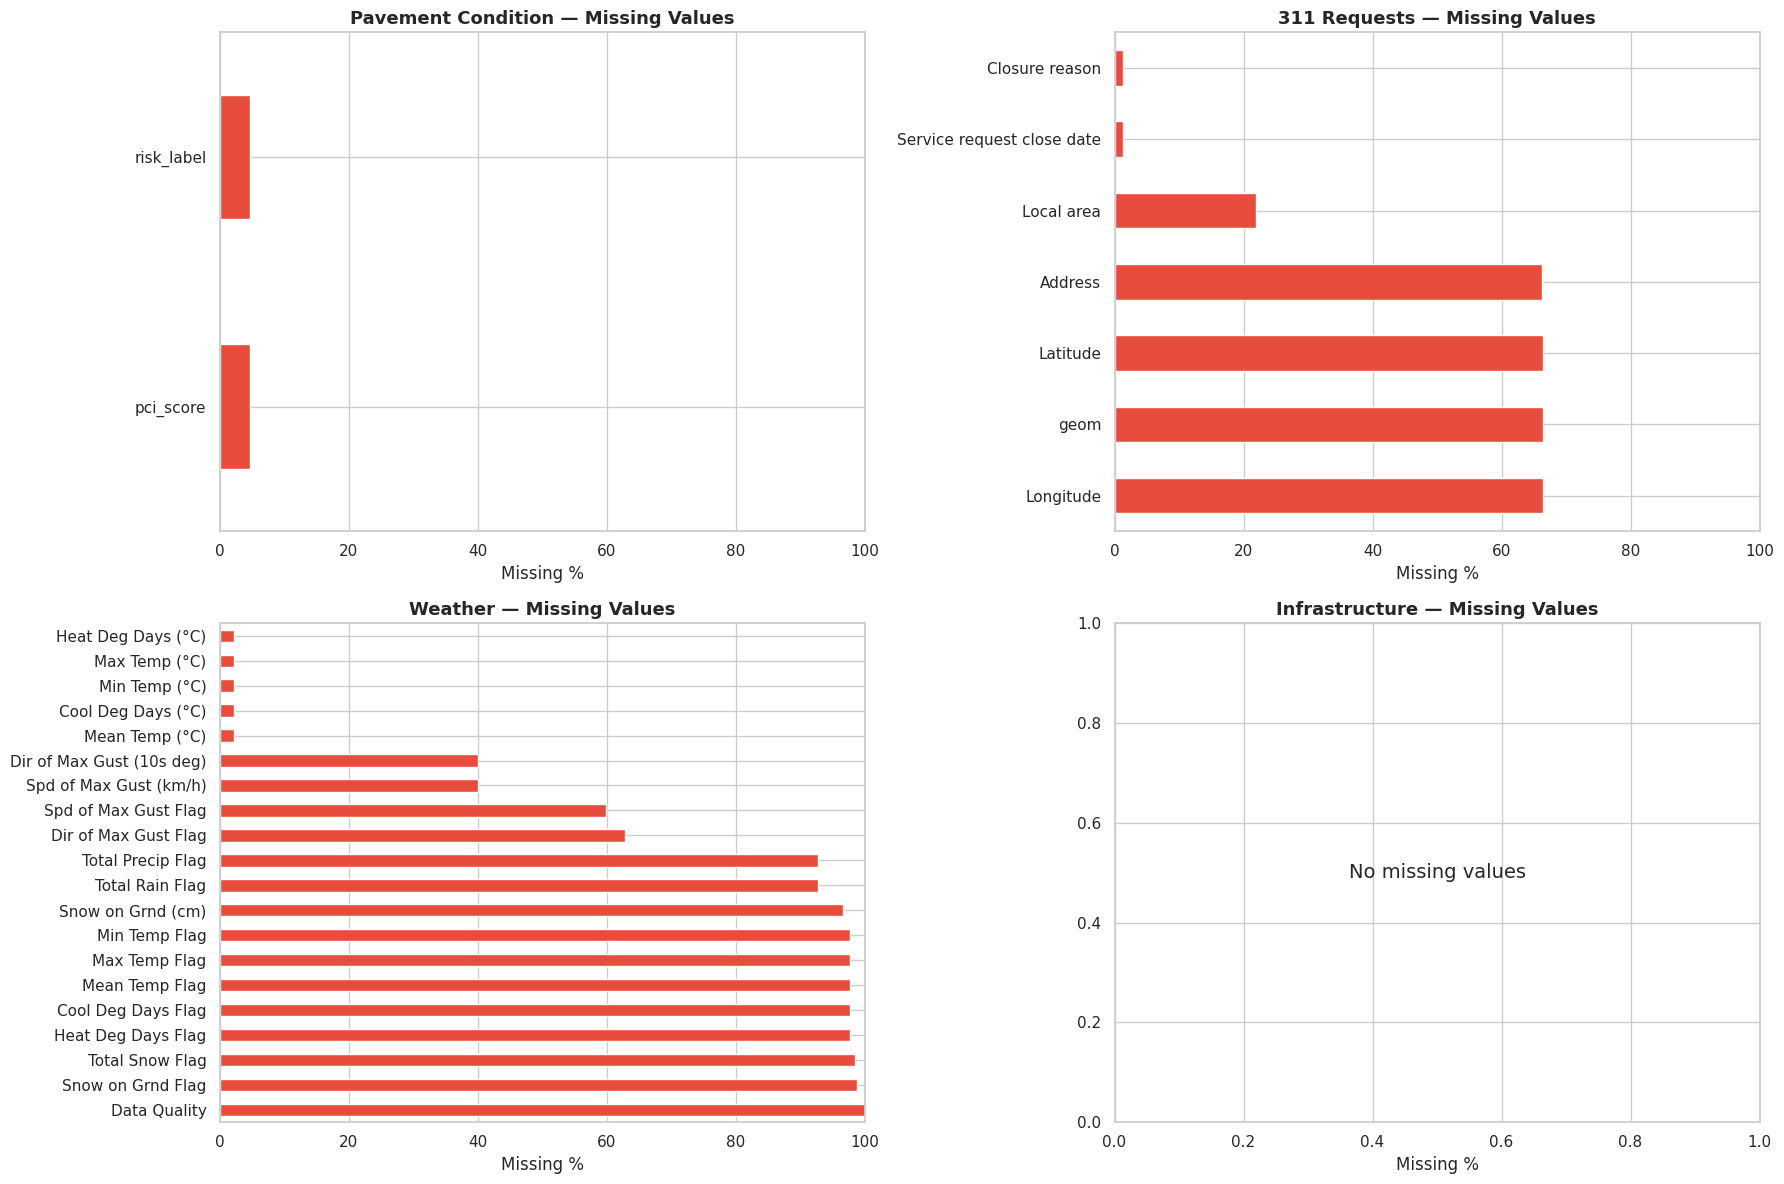

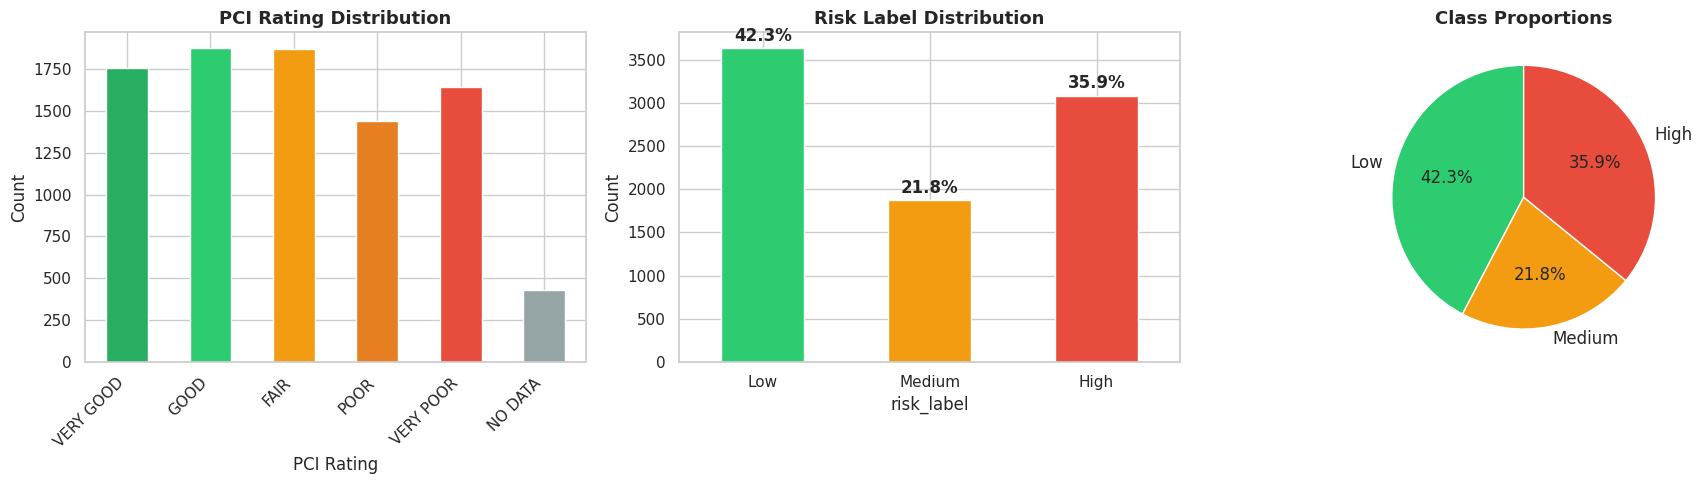

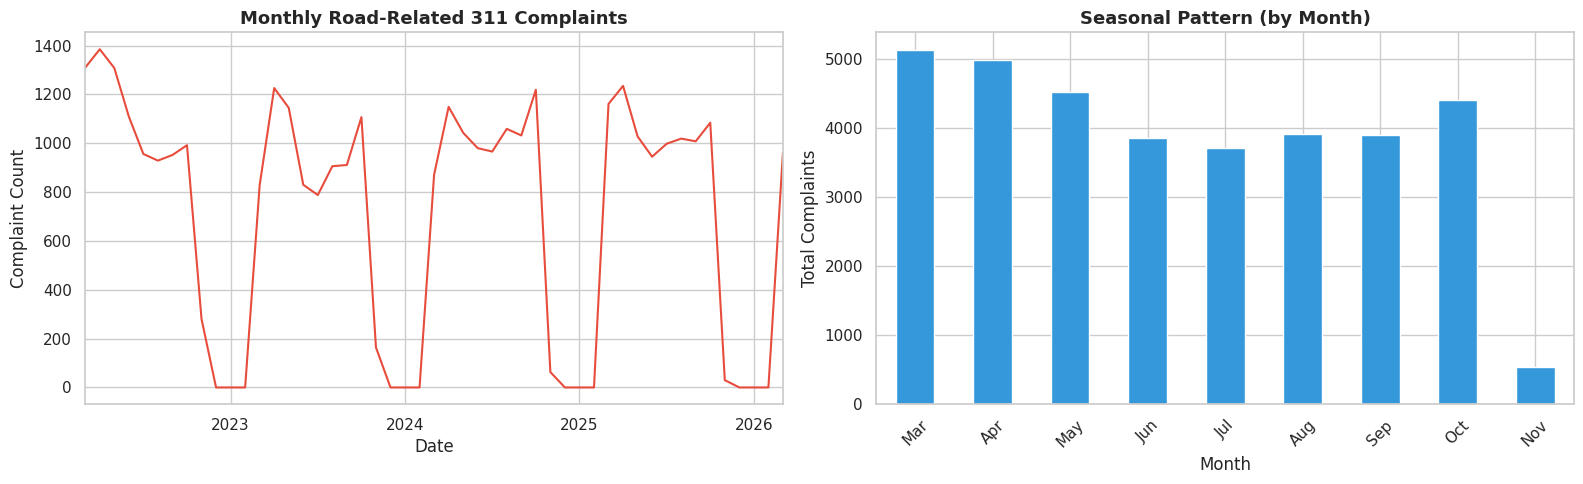

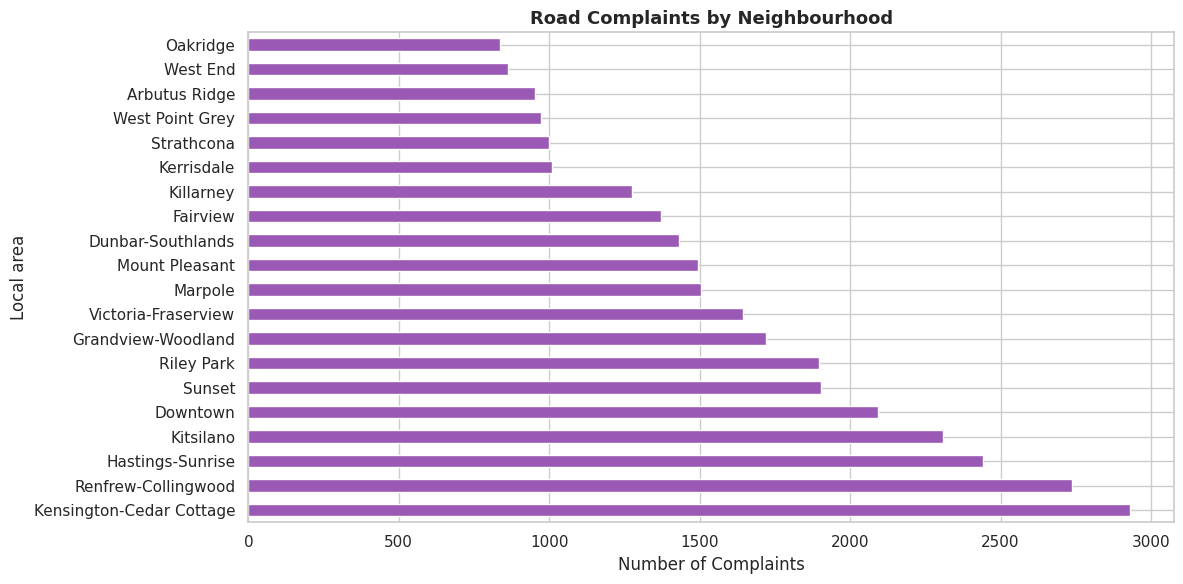

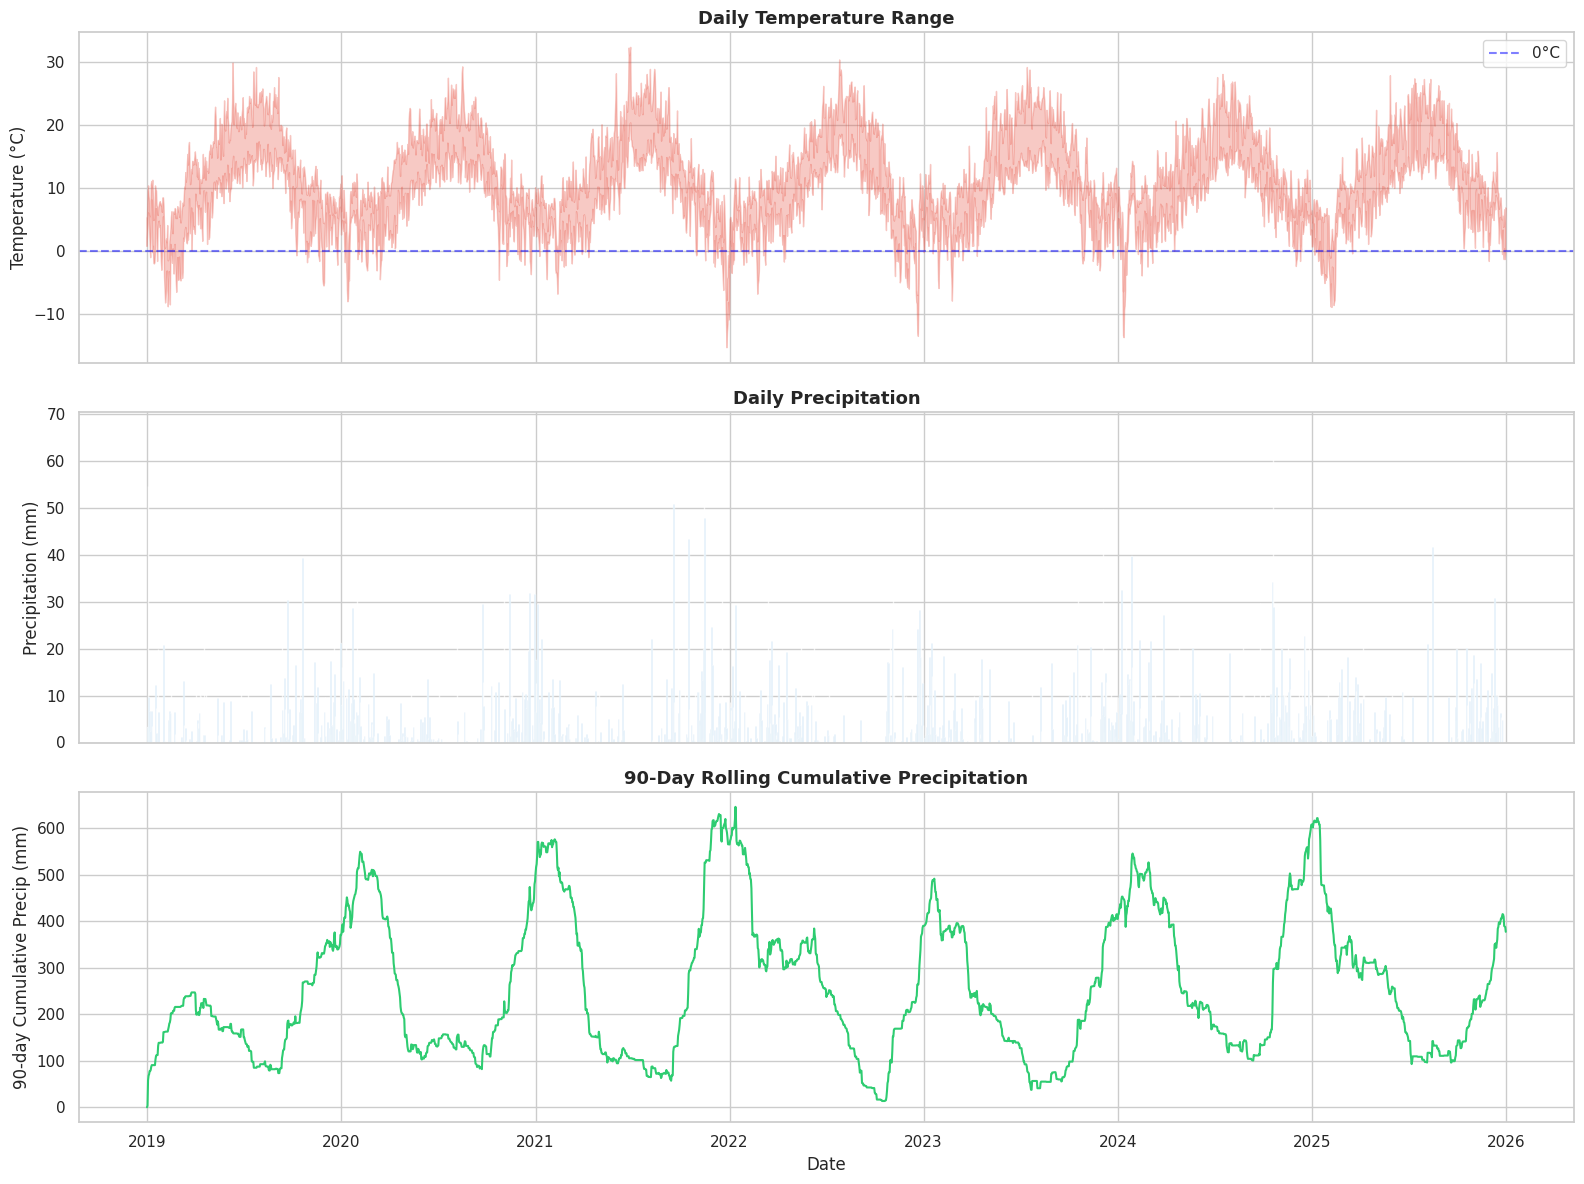

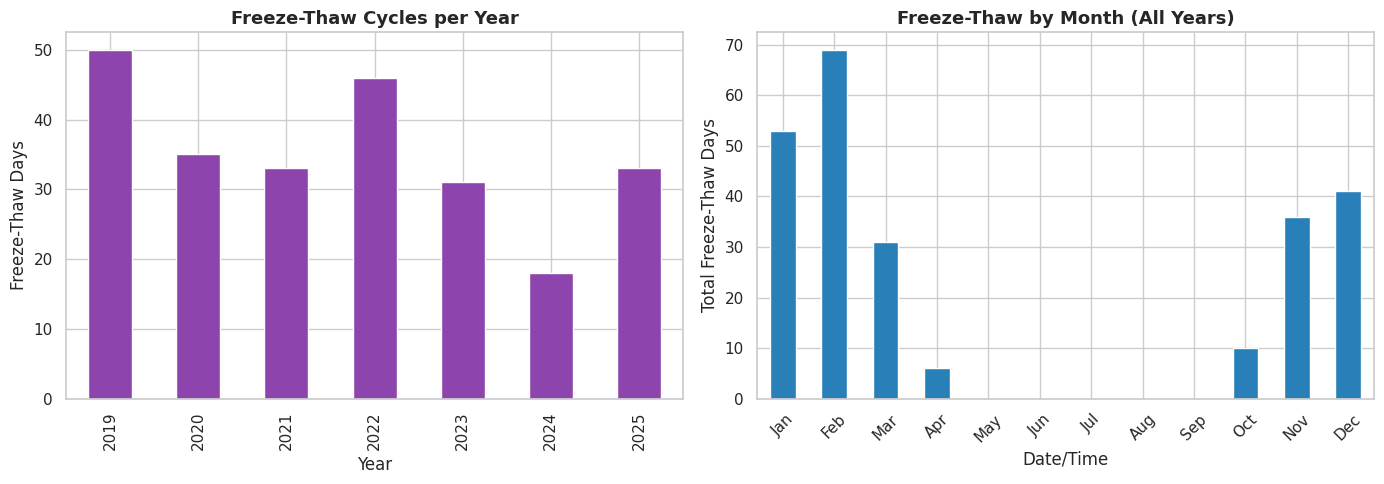

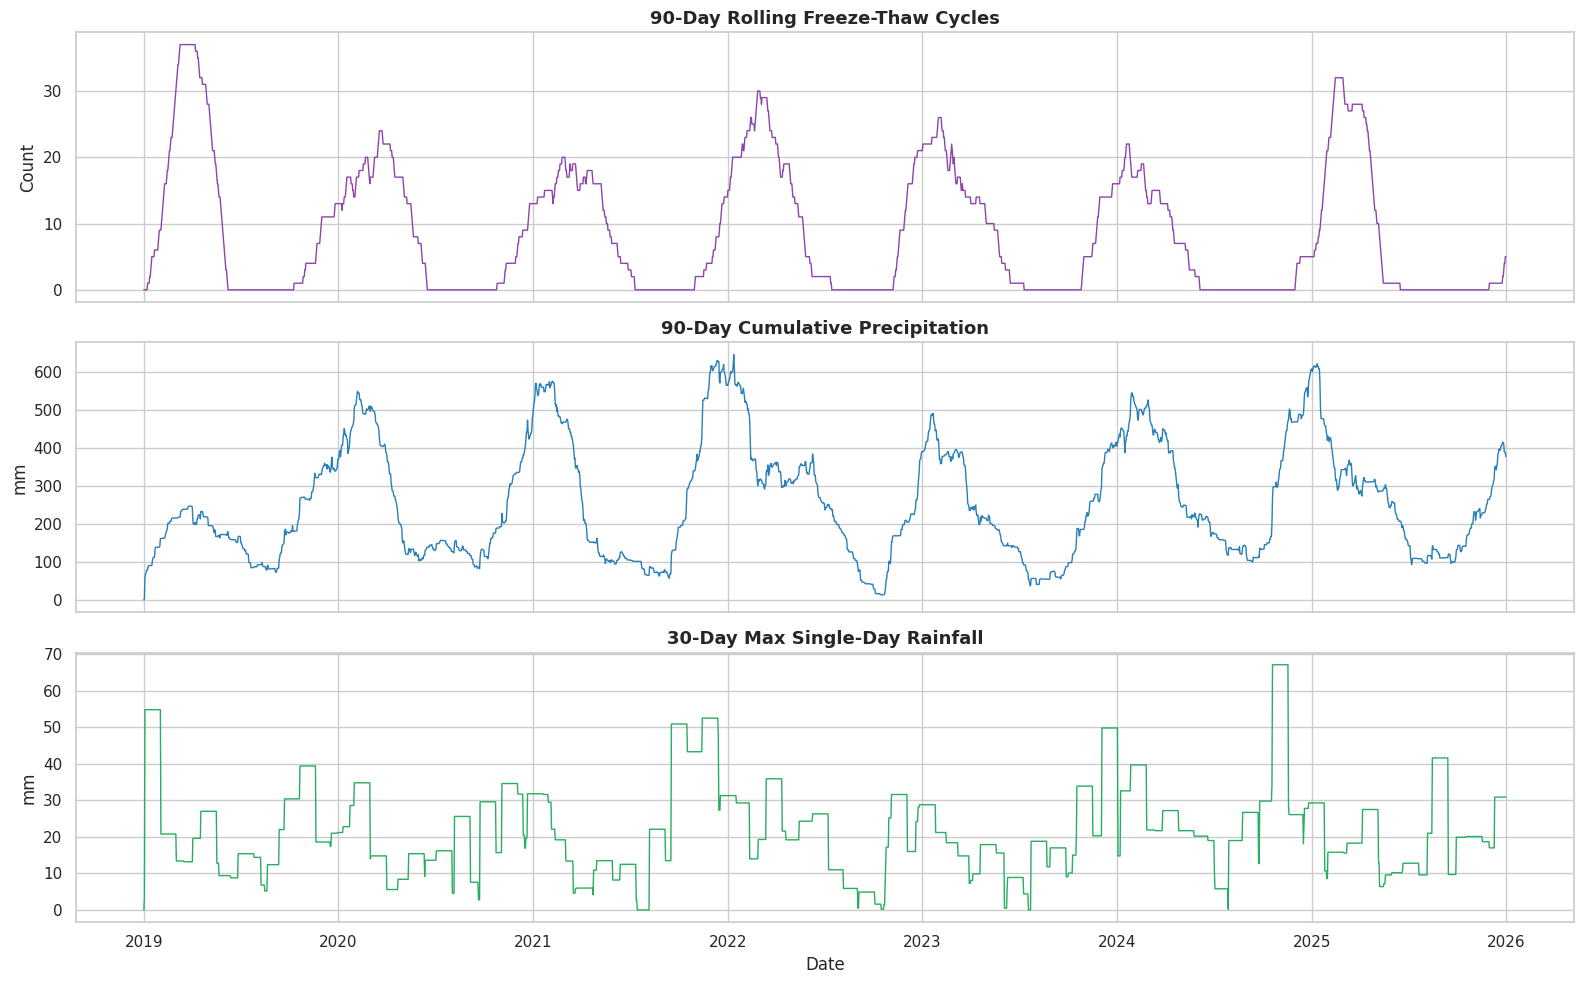

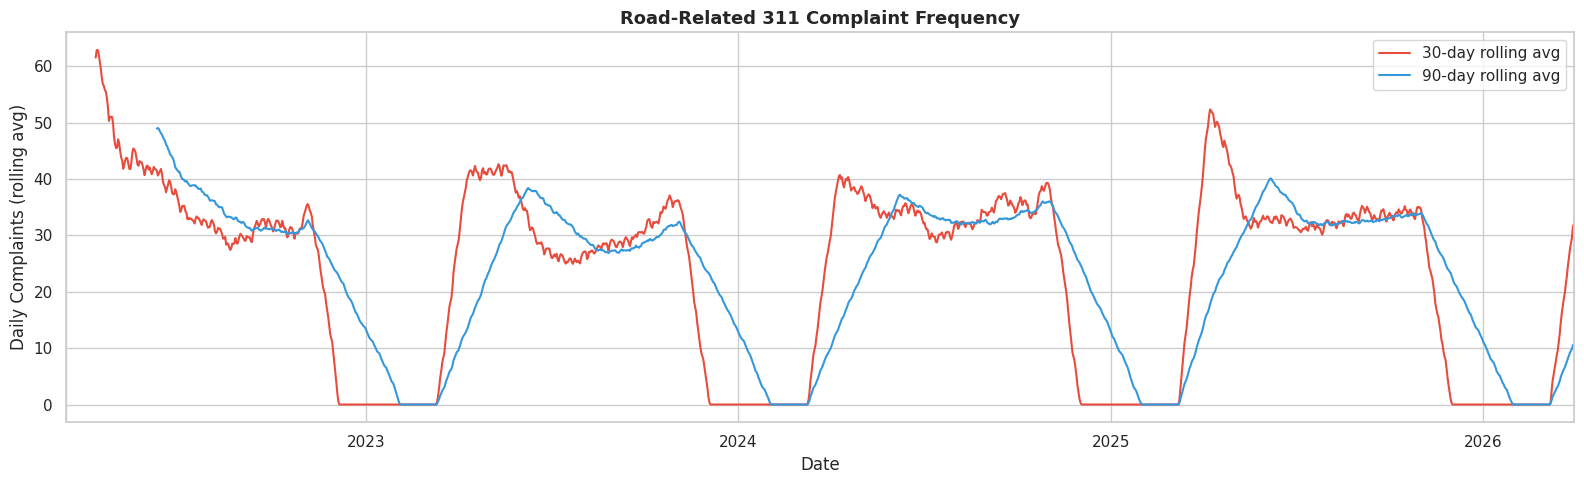

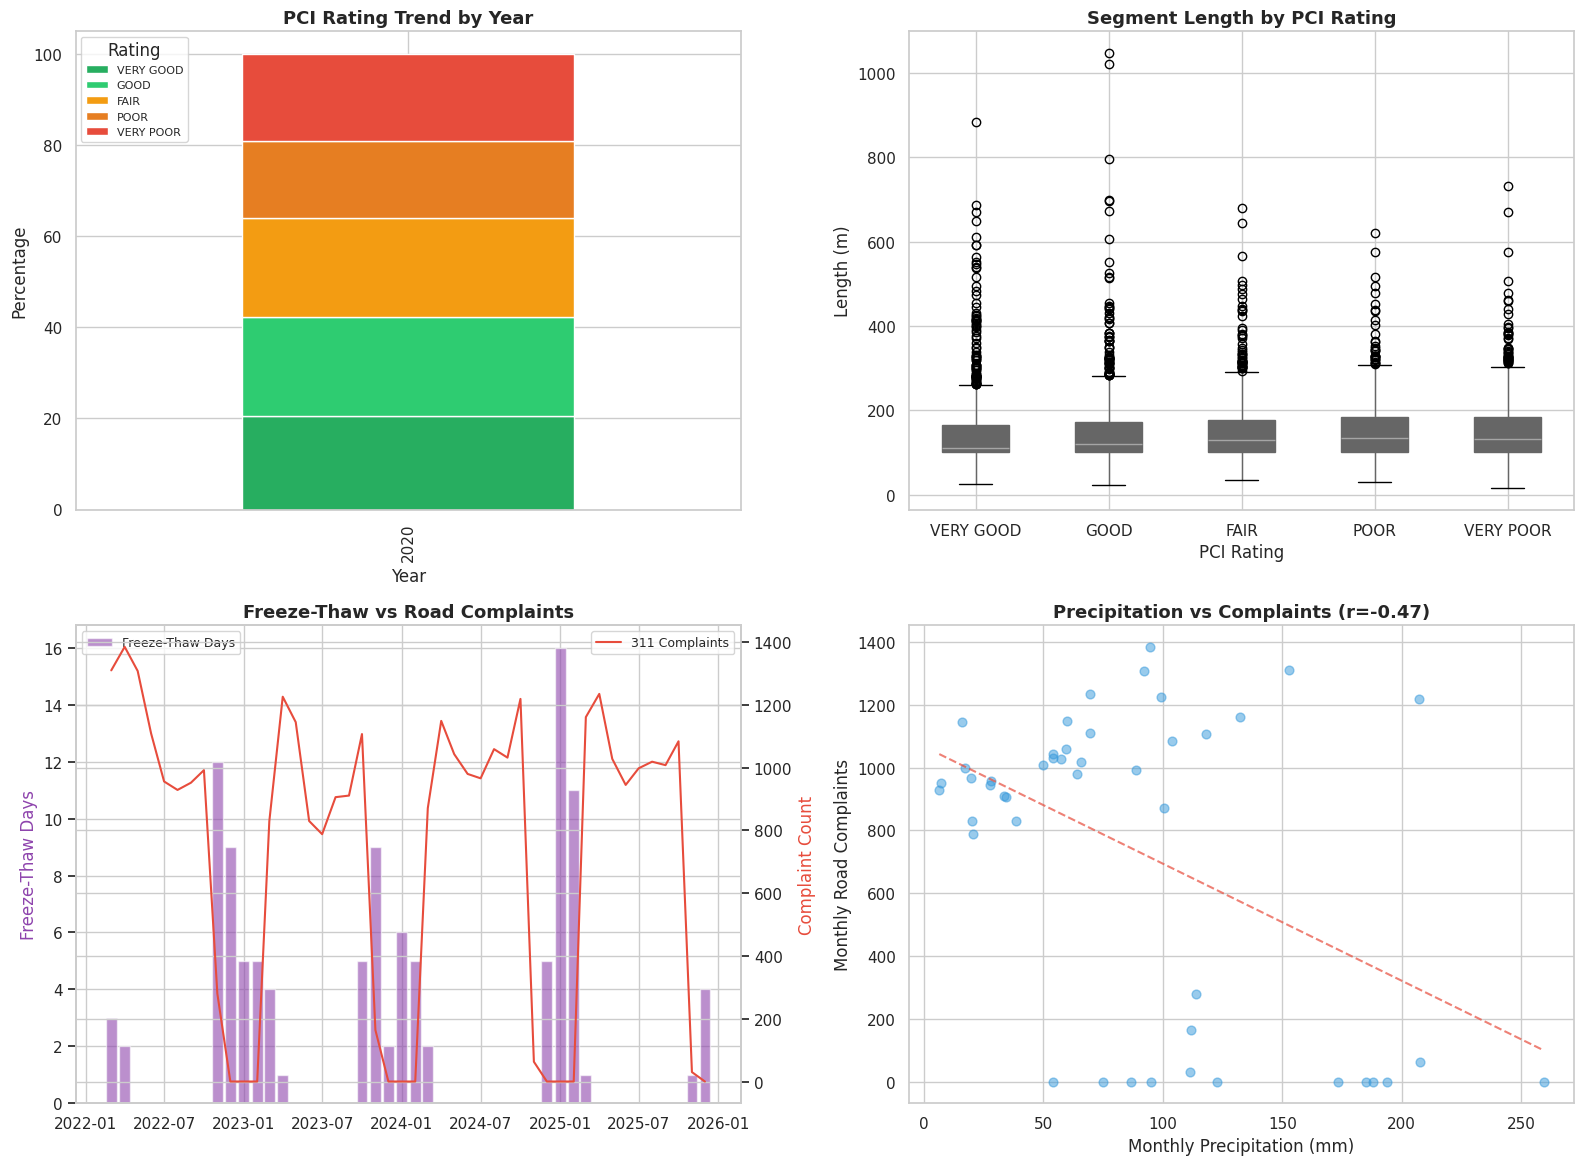


All figures saved to: /content/drive/MyDrive/CityBrain_EDA_Figures/
  01_missing_values.png
  02_risk_label_distribution.png
  03_311_temporal.png
  04_311_neighbourhood_bias.png
  05_weather_timeseries.png
  06_freeze_thaw.png
  07_weather_features.png
  08_311_frequency.png
  09_cross_dataset_analysis.png


In [35]:
# === Save all figures to Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/CityBrain_EDA_Figures/'
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 1) Missing Values ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
datasets_dict = {'Pavement Condition': df_pavement, '311 Requests': df_311, 'Weather': df_weather, 'Infrastructure': df_infra}
for ax, (name, df) in zip(axes.flat, datasets_dict.items()):
    missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0].head(20)
    if len(missing_pct) == 0:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=14)
    else:
        missing_pct.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
        ax.set_xlim(0, 100)
    ax.set_xlabel('Missing %')
    ax.set_title(f'{name} — Missing Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 2) Risk Label Distribution ---
if PCI_COL is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR', 'NO DATA']
    cat_counts = df_pavement[PCI_COL].str.upper().str.strip().value_counts().reindex(order).dropna()
    cat_colors = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#95a5a6']
    cat_counts.plot(kind='bar', ax=axes[0], color=cat_colors[:len(cat_counts)], edgecolor='white')
    axes[0].set_title('PCI Rating Distribution', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    risk_counts = df_pavement['risk_label'].value_counts().reindex(['Low', 'Medium', 'High']).dropna()
    colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    risk_counts.plot(kind='bar', ax=axes[1], color=[colors.get(c, '#999') for c in risk_counts.index], edgecolor='white')
    axes[1].set_title('Risk Label Distribution', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    total = risk_counts.sum()
    for j, (label, count) in enumerate(risk_counts.items()):
        axes[1].text(j, count + total * 0.01, f'{count/total*100:.1f}%', ha='center', fontweight='bold')
    risk_pct = risk_counts / total * 100
    axes[2].pie(risk_pct, labels=risk_pct.index, autopct='%1.1f%%',
                colors=[colors.get(c, '#999') for c in risk_pct.index], startangle=90, textprops={'fontsize': 12})
    axes[2].set_title('Class Proportions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}02_risk_label_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 3) 311 Temporal ---
if DATE_COL_311:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    monthly = df_311_road.set_index(DATE_COL_311).resample('M').size()
    monthly.plot(ax=axes[0], color='#e74c3c', linewidth=1.5)
    axes[0].set_title('Monthly Road-Related 311 Complaints', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Complaint Count')
    seasonal = df_311_road.groupby(df_311_road[DATE_COL_311].dt.month).size()
    seasonal.plot(kind='bar', ax=axes[1], color='#3498db', edgecolor='white')
    axes[1].set_title('Seasonal Pattern (by Month)', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Total Complaints')
    month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    axes[1].set_xticklabels([month_names.get(int(t.get_text()), t.get_text()) for t in axes[1].get_xticklabels()], rotation=45)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}03_311_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 4) 311 Neighbourhood Bias ---
if area_col:
    fig, ax = plt.subplots(figsize=(12, 6))
    area_counts = df_311_road[area_col].value_counts().head(20)
    area_counts.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='white')
    ax.set_title('Road Complaints by Neighbourhood', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Complaints')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}04_311_neighbourhood_bias.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 5) Weather Time Series ---
if date_col_w and temp_min_col and precip_col:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
    if temp_max_col:
        axes[0].fill_between(df_weather[date_col_w],
                             pd.to_numeric(df_weather[temp_min_col], errors='coerce'),
                             pd.to_numeric(df_weather[temp_max_col], errors='coerce'),
                             alpha=0.3, color='#e74c3c')
    axes[0].axhline(0, color='blue', linestyle='--', alpha=0.5, label='0°C')
    axes[0].set_ylabel('Temperature (°C)')
    axes[0].set_title('Daily Temperature Range', fontsize=13, fontweight='bold')
    axes[0].legend()
    precip_vals = pd.to_numeric(df_weather[precip_col], errors='coerce')
    axes[1].bar(df_weather[date_col_w], precip_vals, width=1, color='#3498db', alpha=0.7)
    axes[1].set_ylabel('Precipitation (mm)')
    axes[1].set_title('Daily Precipitation', fontsize=13, fontweight='bold')
    rolling_precip = precip_vals.rolling(90, min_periods=1).sum()
    axes[2].plot(df_weather[date_col_w], rolling_precip, color='#2ecc71', linewidth=1.5)
    axes[2].set_ylabel('90-day Cumulative Precip (mm)')
    axes[2].set_title('90-Day Rolling Cumulative Precipitation', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Date')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}05_weather_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 6) Freeze-Thaw Analysis ---
if 'freeze_thaw' in df_weather.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ft_by_year = df_weather.groupby(df_weather[date_col_w].dt.year)['freeze_thaw'].sum()
    ft_by_year.plot(kind='bar', ax=axes[0], color='#8e44ad', edgecolor='white')
    axes[0].set_title('Freeze-Thaw Cycles per Year', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Freeze-Thaw Days')
    axes[0].set_xlabel('Year')
    ft_by_month = df_weather.groupby(df_weather[date_col_w].dt.month)['freeze_thaw'].sum()
    ft_by_month.plot(kind='bar', ax=axes[1], color='#2980b9', edgecolor='white')
    axes[1].set_title('Freeze-Thaw by Month (All Years)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Total Freeze-Thaw Days')
    month_names2 = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
    axes[1].set_xticklabels([month_names2.get(int(t.get_text()), t.get_text()) for t in axes[1].get_xticklabels()], rotation=45)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}06_freeze_thaw.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 7) Weather Features Preview ---
if date_col_w and precip_col and temp_min_col and temp_max_col:
    precip_v = pd.to_numeric(df_weather[precip_col], errors='coerce').fillna(0)
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
    axes[0].plot(df_weather[date_col_w], df_weather['freeze_thaw'].astype(int).rolling(90, min_periods=1).sum(), color='#8e44ad', linewidth=1)
    axes[0].set_ylabel('Count')
    axes[0].set_title('90-Day Rolling Freeze-Thaw Cycles', fontsize=13, fontweight='bold')
    axes[1].plot(df_weather[date_col_w], precip_v.rolling(90, min_periods=1).sum(), color='#2980b9', linewidth=1)
    axes[1].set_ylabel('mm')
    axes[1].set_title('90-Day Cumulative Precipitation', fontsize=13, fontweight='bold')
    axes[2].plot(df_weather[date_col_w], precip_v.rolling(30, min_periods=1).max(), color='#27ae60', linewidth=1)
    axes[2].set_ylabel('mm')
    axes[2].set_title('30-Day Max Single-Day Rainfall', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Date')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}07_weather_features.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 8) 311 Frequency Time Series ---
if DATE_COL_311:
    daily_complaints = df_311_road.set_index(DATE_COL_311).resample('D').size()
    fig, ax = plt.subplots(figsize=(16, 5))
    daily_complaints.rolling(30).mean().plot(ax=ax, label='30-day rolling avg', color='#e74c3c', linewidth=1.5)
    daily_complaints.rolling(90).mean().plot(ax=ax, label='90-day rolling avg', color='#3498db', linewidth=1.5)
    ax.set_title('Road-Related 311 Complaint Frequency', fontsize=13, fontweight='bold')
    ax.set_ylabel('Daily Complaints (rolling avg)')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}08_311_frequency.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- 9) Cross-Dataset Analysis ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
if PCI_COL and 'Year' in df_pavement.columns:
    order = ['VERY GOOD', 'GOOD', 'FAIR', 'POOR', 'VERY POOR']
    df_pav_clean = df_pavement[df_pavement[PCI_COL].str.upper().str.strip().isin(order)].copy()
    ct = pd.crosstab(df_pav_clean['Year'], df_pav_clean[PCI_COL].str.upper().str.strip(), normalize='index') * 100
    ct = ct[[c for c in order if c in ct.columns]]
    ct.plot(kind='bar', stacked=True, ax=axes[0, 0], color=['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
    axes[0, 0].set_title('PCI Rating Trend by Year', fontsize=13, fontweight='bold')
    axes[0, 0].set_ylabel('Percentage')
    axes[0, 0].legend(title='Rating', fontsize=8, loc='upper left')
if PCI_COL and 'length_(m)' in df_pavement.columns:
    df_pav_clean2 = df_pavement[df_pavement[PCI_COL].str.upper().str.strip().isin(order)].copy()
    df_pav_clean2['_pci'] = pd.Categorical(df_pav_clean2[PCI_COL].str.upper().str.strip(), categories=order, ordered=True)
    df_pav_clean2.boxplot(column='length_(m)', by='_pci', ax=axes[0, 1], patch_artist=True)
    axes[0, 1].set_title('Segment Length by PCI Rating', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('PCI Rating')
    axes[0, 1].set_ylabel('Length (m)')
    plt.sca(axes[0, 1])
    plt.suptitle('')
if weather_monthly_ft is not None and complaints_monthly is not None:
    df_merge = pd.DataFrame({'freeze_thaw': weather_monthly_ft.values, 'month': weather_monthly_ft.index.to_period('M')}).merge(
        pd.DataFrame({'complaints': complaints_monthly.values, 'month': complaints_monthly.index.to_period('M')}), on='month', how='inner')
    if len(df_merge) > 0:
        months = df_merge['month'].dt.to_timestamp()
        axes[1, 0].bar(months, df_merge['freeze_thaw'], width=25, alpha=0.6, color='#8e44ad', label='Freeze-Thaw Days')
        ax3b = axes[1, 0].twinx()
        ax3b.plot(months, df_merge['complaints'], color='#e74c3c', linewidth=1.5, label='311 Complaints')
        axes[1, 0].set_title('Freeze-Thaw vs Road Complaints', fontsize=13, fontweight='bold')
        axes[1, 0].set_ylabel('Freeze-Thaw Days', color='#8e44ad')
        ax3b.set_ylabel('Complaint Count', color='#e74c3c')
        axes[1, 0].legend(loc='upper left', fontsize=9)
        ax3b.legend(loc='upper right', fontsize=9)
if precip_monthly is not None and complaints_monthly is not None:
    df_merge2 = pd.DataFrame({'precip': precip_monthly.values, 'month': precip_monthly.index.to_period('M')}).merge(
        pd.DataFrame({'complaints': complaints_monthly.values, 'month': complaints_monthly.index.to_period('M')}), on='month', how='inner')
    if len(df_merge2) > 0:
        axes[1, 1].scatter(df_merge2['precip'], df_merge2['complaints'], alpha=0.5, color='#3498db', s=40)
        x = df_merge2['precip'].values.astype(float)
        y = df_merge2['complaints'].values.astype(float)
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() > 2:
            from numpy.polynomial.polynomial import polyfit
            b, m = polyfit(x[mask], y[mask], 1)
            xs = np.linspace(x[mask].min(), x[mask].max(), 100)
            axes[1, 1].plot(xs, b + m * xs, '--', color='#e74c3c', alpha=0.7)
            corr_val = np.corrcoef(x[mask], y[mask])[0, 1]
            axes[1, 1].set_title(f'Precipitation vs Complaints (r={corr_val:.2f})', fontsize=13, fontweight='bold')
        axes[1, 1].set_xlabel('Monthly Precipitation (mm)')
        axes[1, 1].set_ylabel('Monthly Road Complaints')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}09_cross_dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAll figures saved to: {SAVE_DIR}')
for f in sorted(os.listdir(SAVE_DIR)):
    if f.endswith('.png'):
        print(f'  {f}')
